# Group 27 — Course-Drop Prediction (Nova Academy)

**Submitters:** Rotem David Semah (ID: `211396593`) · Ron Drach (ID: `213915499`)

---

This is the **current integrated CRISP-DM-style analysis notebook** for the project. It tells the story end to end: business understanding → data exploration → cleaning → feature engineering → modelling → evaluation → interpretation → conclusions.

It combines two exploratory lines of work (`notebook_v1.py` and `Project_Ron_V3.ipynb`) around the selected chronological pipeline, whose clean runnable form lives in `pipelines/pipeline_v2.py`. Running this notebook top to bottom rebuilds the current submission logic.

**The one idea that shaped the modelling choices:** the hidden test set is the **future** — it begins exactly where training ends and runs four months further. So the task is _forecasting_, not interpolating, and any validation that mixes past and future rows (a random split) is measuring the wrong thing. Respecting time in validation helped explain the improvement from the first submission's **0.886** leaderboard AUC to the current **0.889314 — 1st of 32 groups**.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["svg.fonttype"] = "path"
try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

# `display` is injected by Jupyter. Define a fallback so the notebook also runs
# as a plain script (e.g. for CI / reproducibility checks).
try:
    display  # noqa: B018
except NameError:  # pragma: no cover

    def display(*objs, **_):
        for o in objs:
            print(o)


TRAIN_PATH = "data/Train_Data.csv"
TEST_PATH = "data/Test_Data_No_Target.csv"
TARGET = "Dropped_Course"
CHRONO_CUTOFF = "2017-01-01"  # validation window ~ 4 months, matching the test window
SEED = 42
GITHUB_RAW_BASES = [
    "https://raw.githubusercontent.com/manemajef/ml-proj/main",
]

pd.set_option("display.max_columns", None)


def load_raw(path: str) -> pd.DataFrame:
    local_path = Path(path)
    read_errors = []

    if local_path.exists():
        source = local_path
    else:
        source = None
        for base_url in GITHUB_RAW_BASES:
            url = f"{base_url}/{path}"
            try:
                df = pd.read_csv(url, parse_dates=["Course_Start_Date"])
                print(f"{path} not found locally; loaded from {url}")
                break
            except Exception as exc:
                read_errors.append(f"{url}: {exc}")
        else:
            tried = "\n".join(read_errors) or "No GitHub fallback URL configured."
            raise FileNotFoundError(
                f"Could not find {path} locally and could not fetch it from GitHub.\n{tried}"
            )

    if source is not None:
        df = pd.read_csv(source, parse_dates=["Course_Start_Date"])

    # Agent/Company IDs are categorical labels, not quantities.
    for col in ("Agent_ID", "Company_ID"):
        df[col] = df[col].astype("string")
    return df

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Business understanding

Nova Academy runs paid, in-person B2B technical trainings. Preparing a course is expensive and largely **sunk before it starts** — cloud environments, catering, physical equipment kits, room capacity. When a registered group cancels (`Dropped_Course = 1`), the company loses that spend _and_ the empty seats block other groups from being scheduled.

**Goal.** Given a new registration, predict the **probability** that it will be cancelled, so operations can manage risk (overbook cautiously, follow up with high-risk groups, hold back irreversible spend).

**Why probability-like scores, not hard labels.** Operations needs to _rank_ and _size_ risk, not receive a yes/no. The grading metric is **AUC** — a threshold-free measure of how well a score ranks droppers above non-droppers. The selected CSV uses a rank-average boosted-tree score optimized for this ranking task; threshold diagnostics below use mean model probabilities separately because the rank score is not calibrated. The passing bar is AUC ≥ 0.70.

**CRISP-DM framing.** The rest of the notebook follows the standard cycle: understand the data, prepare it, model, evaluate, and translate results back into business insight.


# 2. Data loading & first look

Two files are provided:

- `Train_Data.csv` — historical registrations **with** the `Dropped_Course`
  label.
- `Test_Data_No_Target.csv` — registrations to score, **without** the label.

If the local `data/` files are missing, `load_raw` falls back to the raw CSVs in the GitHub repository. This keeps the notebook runnable when shared as a single `.ipynb`, as long as the machine has internet access and the repository data files are reachable.

Each row is one order (`Client_ID`). We load both and immediately build a data dictionary: dtype, missingness, cardinality, mode, and a zero-count (some "zeros" are really missing-in-disguise).


In [2]:
train_raw = load_raw(TRAIN_PATH)
test_raw = load_raw(TEST_PATH)

print(f"train: {train_raw.shape[0]:,} rows x {train_raw.shape[1]} cols")
print(f"test : {test_raw.shape[0]:,} rows x {test_raw.shape[1]} cols")

data_dictionary = pd.DataFrame({
    "dtype": train_raw.dtypes.astype(str),
    "n_missing": train_raw.isna().sum(),
    "missing_%": (train_raw.isna().mean() * 100).round(2),
    "n_unique": train_raw.nunique(dropna=True),
    "n_zero": (train_raw == 0).sum(numeric_only=False),
    "most_frequent": train_raw.mode(dropna=True).iloc[0],
})
display(data_dictionary)

train: 63,464 rows x 29 cols
test : 15,866 rows x 28 cols


,dtype,n_missing,missing_%,n_unique,n_zero,most_frequent
Client_ID,int64,0,0.00,63464,0,1
Professionals_Count,int64,0,0.00,5,338,2.0
Students_Count,float64,4,0.01,5,59578,0.0
Observers_Count,int64,0,0.00,5,63149,0.0
Course_Start_Date,datetime64[ns],0,0.00,666,0,2015-10-16 00:00:00
Practical_Hours,int64,0,0.00,18,30671,0.0
Theory_Hours,int64,0,0.00,29,4045,2.0
Registration_Days_Before,float64,2666,4.20,423,2610,0.0
Origin_Country,object,557,0.88,721,0,PRT
Catering_Package,object,407,0.64,321,0,Standard (Coffee Only)


**What the dictionary tells us.**

- `Client_ID` is unique per row — an identifier, never a feature.
- `Agent_ID`, `Company_ID`, `Origin_Country` are **high-cardinality**
  identifiers (many distinct values). `Company_ID` is missing for most rows.
- A handful of numeric columns show impossible extremes in `describe()` below
  (e.g. `Students_Count = 9999`, `Practical_Hours = 10000`) — flagged for the
  outlier section.
- The categorical text columns are visibly _dirty_ (casing, punctuation,
  placeholder strings) — handled in cleaning.


In [3]:
display(train_raw.describe())

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Daily_Tuition_Cost,Dropped_Course
count,63464.000000,63464.000000,63460.000000,63464.000000,63464,63464.000000,63464.000000,60798.000000,63464.000000,63464.000000,63464.000000,62424.000000,63464.000000,63464.000000,63464.000000,63385.000000,63464.000000
mean,39761.752616,1.835214,8.751718,0.005326,2016-06-23 05:17:23.287533056,6.609054,2.164392,102.894470,0.095991,0.122967,0.513330,0.026224,3.983676,0.180039,0.027133,98.847963,0.414392
min,1.000000,0.000000,0.000000,0.000000,2015-07-01 00:00:00,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19959.750000,2.000000,0.000000,0.000000,2016-02-13 00:00:00,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,75.000000,0.000000
50%,39819.500000,2.000000,0.000000,0.000000,2016-07-01 00:00:00,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.500000,0.000000
75%,59570.250000,2.000000,0.000000,0.000000,2016-11-11 00:00:00,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,117.000000,1.000000
max,79330.000000,4.000000,9999.000000,10.000000,2017-04-26 00:00:00,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,5400.000000,1.000000
std,22878.980699,0.508607,294.238584,0.089662,NaN,215.502929,1.469854,109.178824,0.448526,1.535201,0.763563,0.160202,23.195495,0.592577,0.162474,41.855391,0.492621


## 2.1 Target balance

Before anything else: how (im)balanced is the target? A heavily skewed target would change how we read metrics.


,count,rate_%
0 = completed,37165,58.6
1 = dropped,26299,41.4


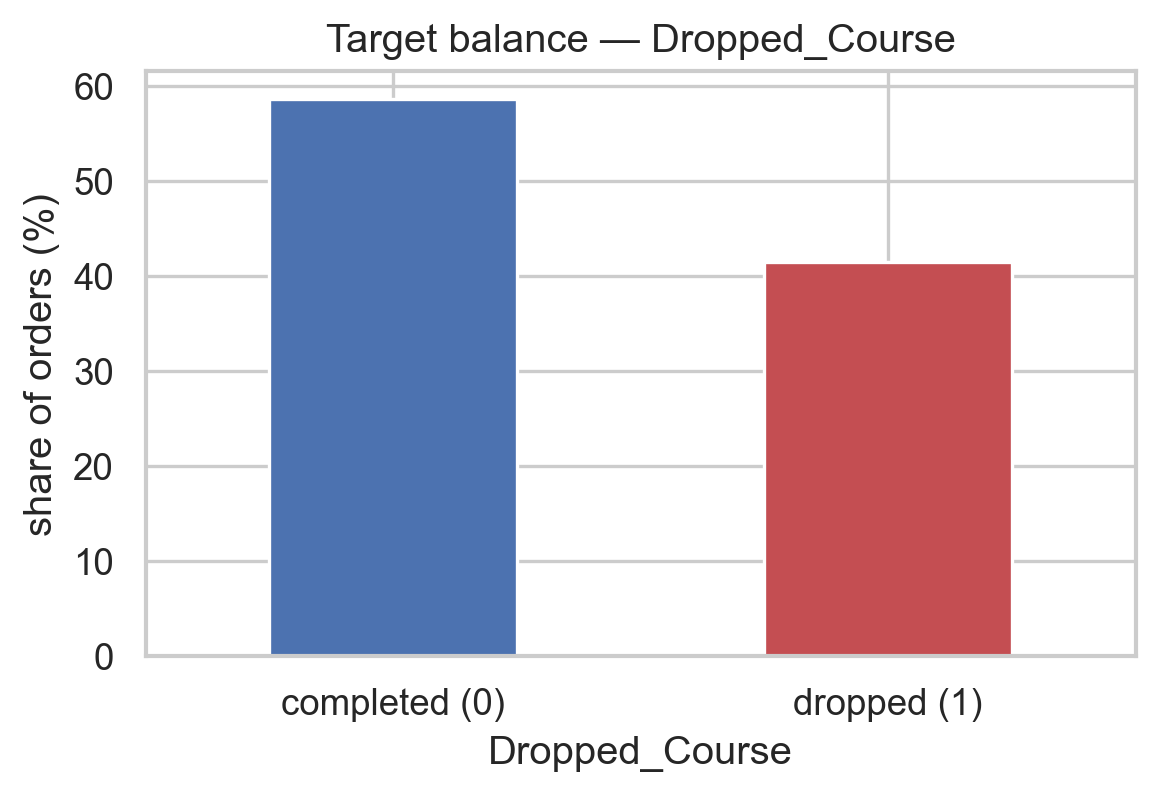

In [4]:
target_counts = train_raw[TARGET].value_counts().sort_index()
target_rate = train_raw[TARGET].value_counts(normalize=True).sort_index()
balance = pd.DataFrame({
    "count": target_counts,
    "rate_%": (target_rate * 100).round(1),
})
balance.index = ["0 = completed", "1 = dropped"]
display(balance)

ax = target_rate.mul(100).plot.bar(color=["#4c72b0", "#c44e52"], figsize=(5, 3.5))
ax.set_xticklabels(["completed (0)", "dropped (1)"], rotation=0)
ax.set_ylabel("share of orders (%)")
ax.set_title("Target balance — Dropped_Course")
plt.tight_layout()
plt.show()

The classes are **roughly balanced** (~59% completed / ~41% dropped). No resampling is needed, and AUC is a sensible, stable choice of metric.


# 3. Exploratory Data Analysis

The EDA has one headline finding that reorganises the whole project (the time structure), plus the usual per-feature analysis. We lead with the headline.


## 3.1 The headline: **the test set is the future**

We plot the monthly drop rate across the _training_ period and overlay where training ends and where the hidden test window ends.


train dates: 2015-07-01 -> 2017-04-26
test  dates: 2017-04-26 -> 2017-08-31


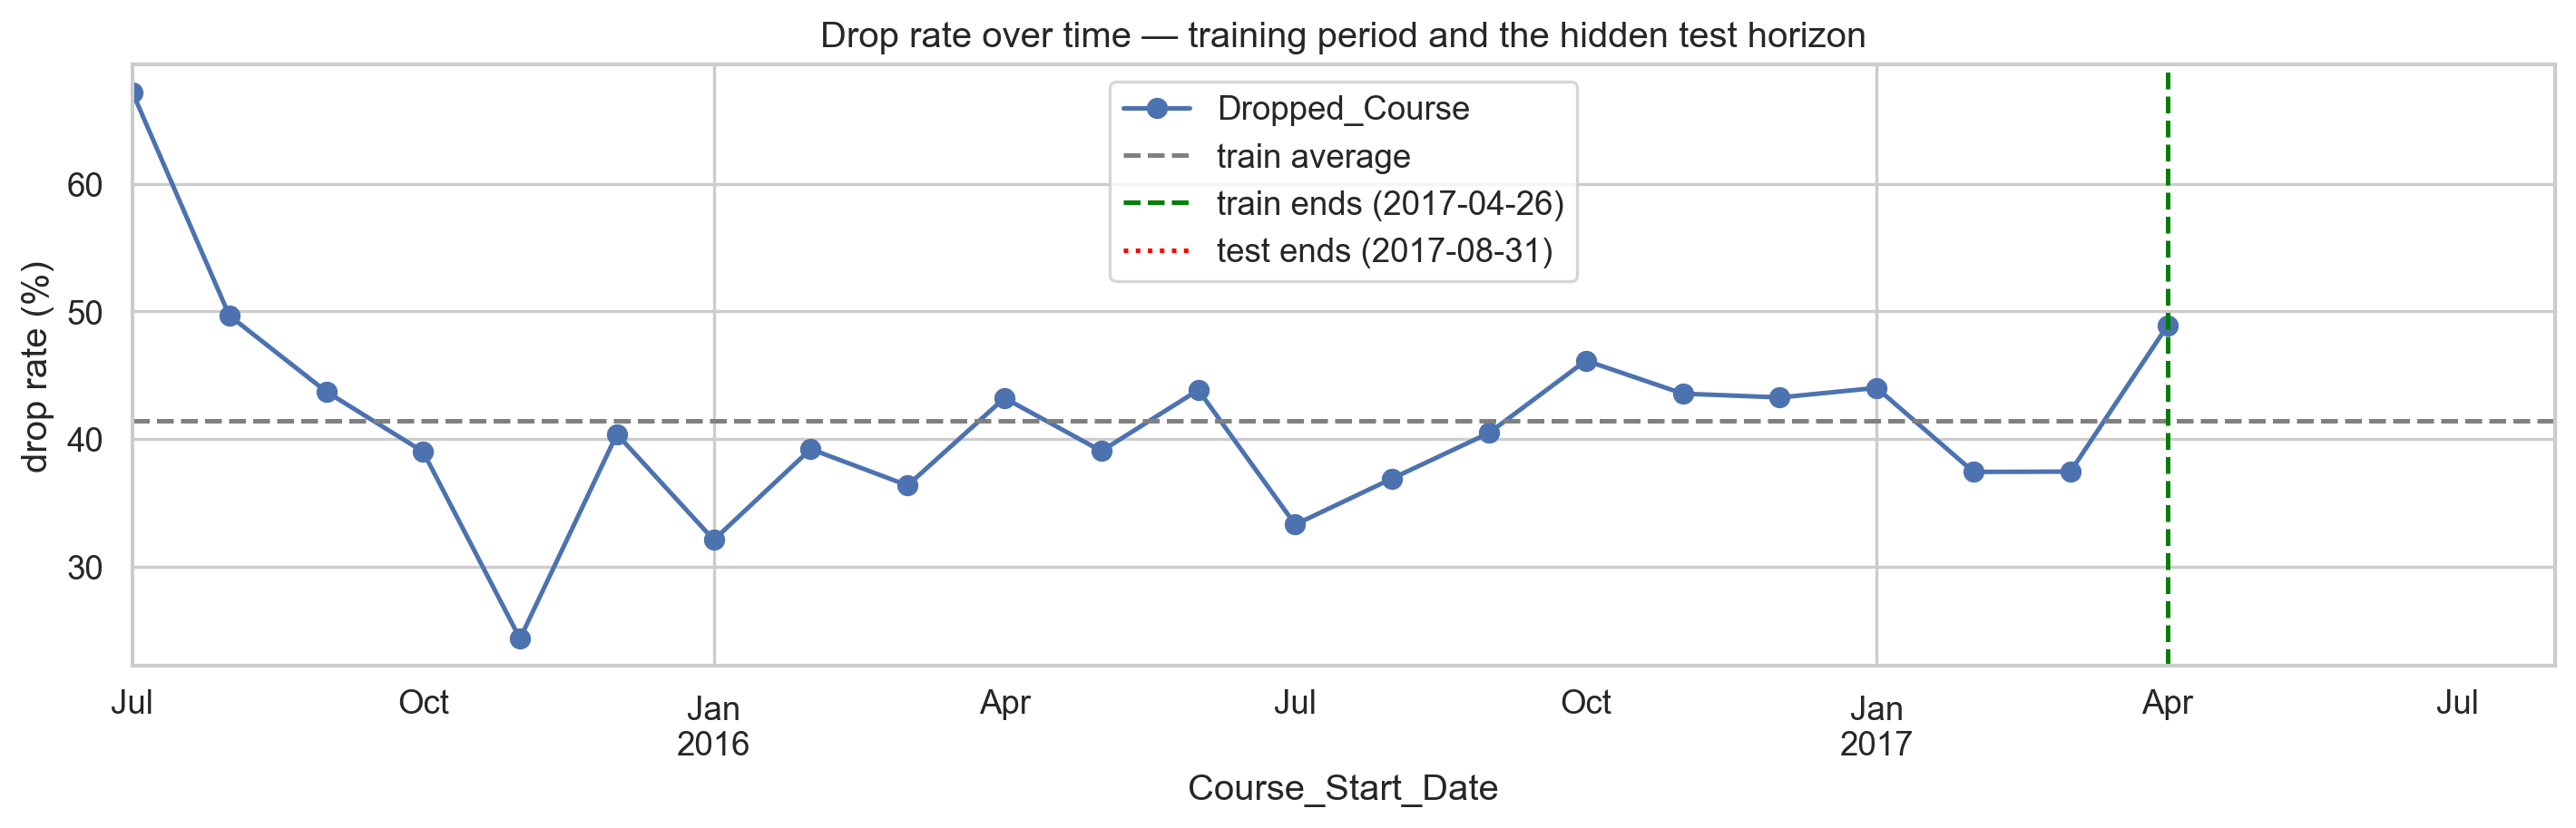

In [5]:
train_end = train_raw["Course_Start_Date"].max()
test_start = test_raw["Course_Start_Date"].min()
test_end = test_raw["Course_Start_Date"].max()

print(
    f"train dates: {train_raw['Course_Start_Date'].min().date()} -> {train_end.date()}"
)
print(f"test  dates: {test_start.date()} -> {test_end.date()}")

monthly = (
    train_raw.set_index("Course_Start_Date").resample("MS")[TARGET].mean().mul(100)
)
ax = monthly.plot(marker="o", figsize=(12, 4))
ax.axhline(train_raw[TARGET].mean() * 100, ls="--", color="grey", label="train average")
ax.axvline(train_end, ls="--", color="green", label=f"train ends ({train_end.date()})")
ax.axvline(test_end, ls=":", color="red", label=f"test ends ({test_end.date()})")
ax.set_xlim(train_raw["Course_Start_Date"].min(), test_end)
ax.set_ylabel("drop rate (%)")
ax.set_title("Drop rate over time — training period and the hidden test horizon")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the plot.** Training runs `2015-07 → 2017-04`; the test window starts exactly where training ends and continues to `2017-08`, with essentially **zero overlap in time**. The drop rate also **drifts year to year** — it is not a stationary process.

**Consequence.** The real task is "train on the past, predict the future". A random train/validation split leaks future rows into training and produces an _optimistic_ score that does not transfer to the leaderboard. This time structure drives our validation strategy (Section 6) and motivates a feature choice (the time index, Section 5). It likely explains much of the gap between random-split validation and leaderboard behavior, while other feature and model changes also contributed.


## 3.2 Missing values

We compare missingness in train vs the official test file (the pipeline must handle both identically), then ask whether _the fact of being missing_ is itself predictive.


In [6]:
missing_compare = pd.DataFrame({
    "train_missing_%": train_raw.isna().mean().mul(100).round(2),
    "test_missing_%": test_raw.isna().mean().mul(100).round(2),
})
missing_compare = missing_compare[
    (missing_compare["train_missing_%"] > 0) | (missing_compare["test_missing_%"] > 0)
].sort_values("train_missing_%", ascending=False)
display(missing_compare)

,train_missing_%,test_missing_%
Company_ID,95.08,96.41
Agent_ID,17.61,17.61
Registration_Days_Before,4.20,4.05
Requested_Lab_Config,2.74,3.01
Physical_Course_Kits,1.64,1.43
Enrollment_Type,1.13,1.12
Submission_Source,0.95,0.94
Payment_Terms,0.92,0.91
Origin_Country,0.88,1.01
Catering_Package,0.64,0.70


Missingness patterns are **consistent between train and test**, so a single imputation policy is safe to reuse for scoring.

**Next**: is missingness itself a signal?


In [7]:
missingness_cols = [
    "Company_ID",
    "Agent_ID",
    "Registration_Days_Before",
    "Physical_Course_Kits",
    "Daily_Tuition_Cost",
    "Payment_Terms",
]
rows = []
for col in missingness_cols:
    stats = (
        train_raw
        .assign(is_missing=train_raw[col].isna())
        .groupby("is_missing")[TARGET]
        .agg(count="size", drop_rate="mean")
    )
    for is_missing, r in stats.iterrows():
        rows.append({
            "column": col,
            "is_missing": is_missing,
            "count": int(r["count"]),
            "drop_rate_%": round(r["drop_rate"] * 100, 1),
        })
display(pd.DataFrame(rows))

,column,is_missing,count,drop_rate_%
0,Company_ID,False,3120,21.2
1,Company_ID,True,60344,42.5
2,Agent_ID,False,52291,43.1
3,Agent_ID,True,11173,33.5
4,Registration_Days_Before,False,60798,41.4
5,Registration_Days_Before,True,2666,41.5
6,Physical_Course_Kits,False,62424,41.5
7,Physical_Course_Kits,True,1040,39.3
8,Daily_Tuition_Cost,False,63385,41.4
9,Daily_Tuition_Cost,True,79,51.9


**Missingness is informative.**

- Rows _without_ a `Company_ID` drop at a noticeably higher rate than rows with one — a registration made through a known company is a more committed order.
- `Agent_ID` missingness shows a different profile too. This justifies explicit **presence flags** (`has_company_id`, `has_agent_id`) rather than silently imputing these away.


## 3.3 Categorical data quality (and why cleaning is mandatory)

Previous exploration showed that the categorical columns are deliberately corrupted: mixed case, injected punctuation (`blu#e` -> `blue`), padded whitespace, and placeholder junk (`unknown`, `?`, `-`, `n/a`). Left raw, the same real category splits into many fake ones, inflating cardinality and diluting signal. We normalise to a canonical lowercase form and map junk to missing.


In [8]:
# The data contains many variations of <na>s,
COMMON_NANS = {
    "",
    "-",
    "--",
    ".",
    "?",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "unknown",
    "unknonwn",
}

COUNTRY_ALIASES = {
    "cn": "chn"
}  # both codes mean China (found in EDA), fount in previous exploration
CAT_COLS = [
    "Origin_Country",
    "Catering_Package",
    "Welcome_Gift_Type",
    "Requested_Lab_Config",
    "Assigned_Lab_Config",
    "Enrollment_Type",
    "Lanyard_Color",
    "Client_Category",
    "Submission_Source",
    "Payment_Terms",
    "Agent_ID",
    "Company_ID",
]


def normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    """Canonicalise dirty categorical text and map junk placeholders to NaN."""
    df = df.copy()
    for col in CAT_COLS:
        s = df[col].astype("string").str.strip().str.lower()
        s = (
            s.str
            .replace(r"\band\b", "&", regex=True)
            .str.replace(r"[^a-z0-9&() .+-]+", "", regex=True)  # strip # ! * ? etc.
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )
        df[col] = s.mask(s.isin(COMMON_NANS))
    df["Origin_Country"] = df["Origin_Country"].replace(COUNTRY_ALIASES)
    return df


def cat_cardinality(df, cols):
    return (
        pd
        .DataFrame({
            "raw_unique": {c: df[c].nunique(dropna=True) for c in cols},
            "clean_unique": {
                c: normalize_cats(df)[c].nunique(dropna=True) for c in cols
            },
        })
        .assign(collapsed=lambda t: t["raw_unique"] - t["clean_unique"])
        .sort_values("collapsed", ascending=False)
    )


low_card = [c for c in CAT_COLS if c not in ("Agent_ID", "Company_ID")]
display(cat_cardinality(train_raw, low_card))

,raw_unique,clean_unique,collapsed
Origin_Country,721,153,568
Client_Category,505,7,498
Submission_Source,328,4,324
Catering_Package,321,4,317
Enrollment_Type,298,4,294
Lanyard_Color,240,5,235
Payment_Terms,236,3,233
Welcome_Gift_Type,4,4,0
Requested_Lab_Config,8,8,0
Assigned_Lab_Config,9,9,0


**Before/after normalisation**, dozens of spurious variants collapse into their true categories (the `collapsed` column). This is data cleaning, not feature engineering, and the _exact same_ function is reused for the test set so the category vocabularies line up.


## 3.4 Which categories actually relate to dropping?

For the cleaned categoricals we plot the drop rate of the most frequent levels against the dataset mean. A level far from the dashed mean line carries signal.


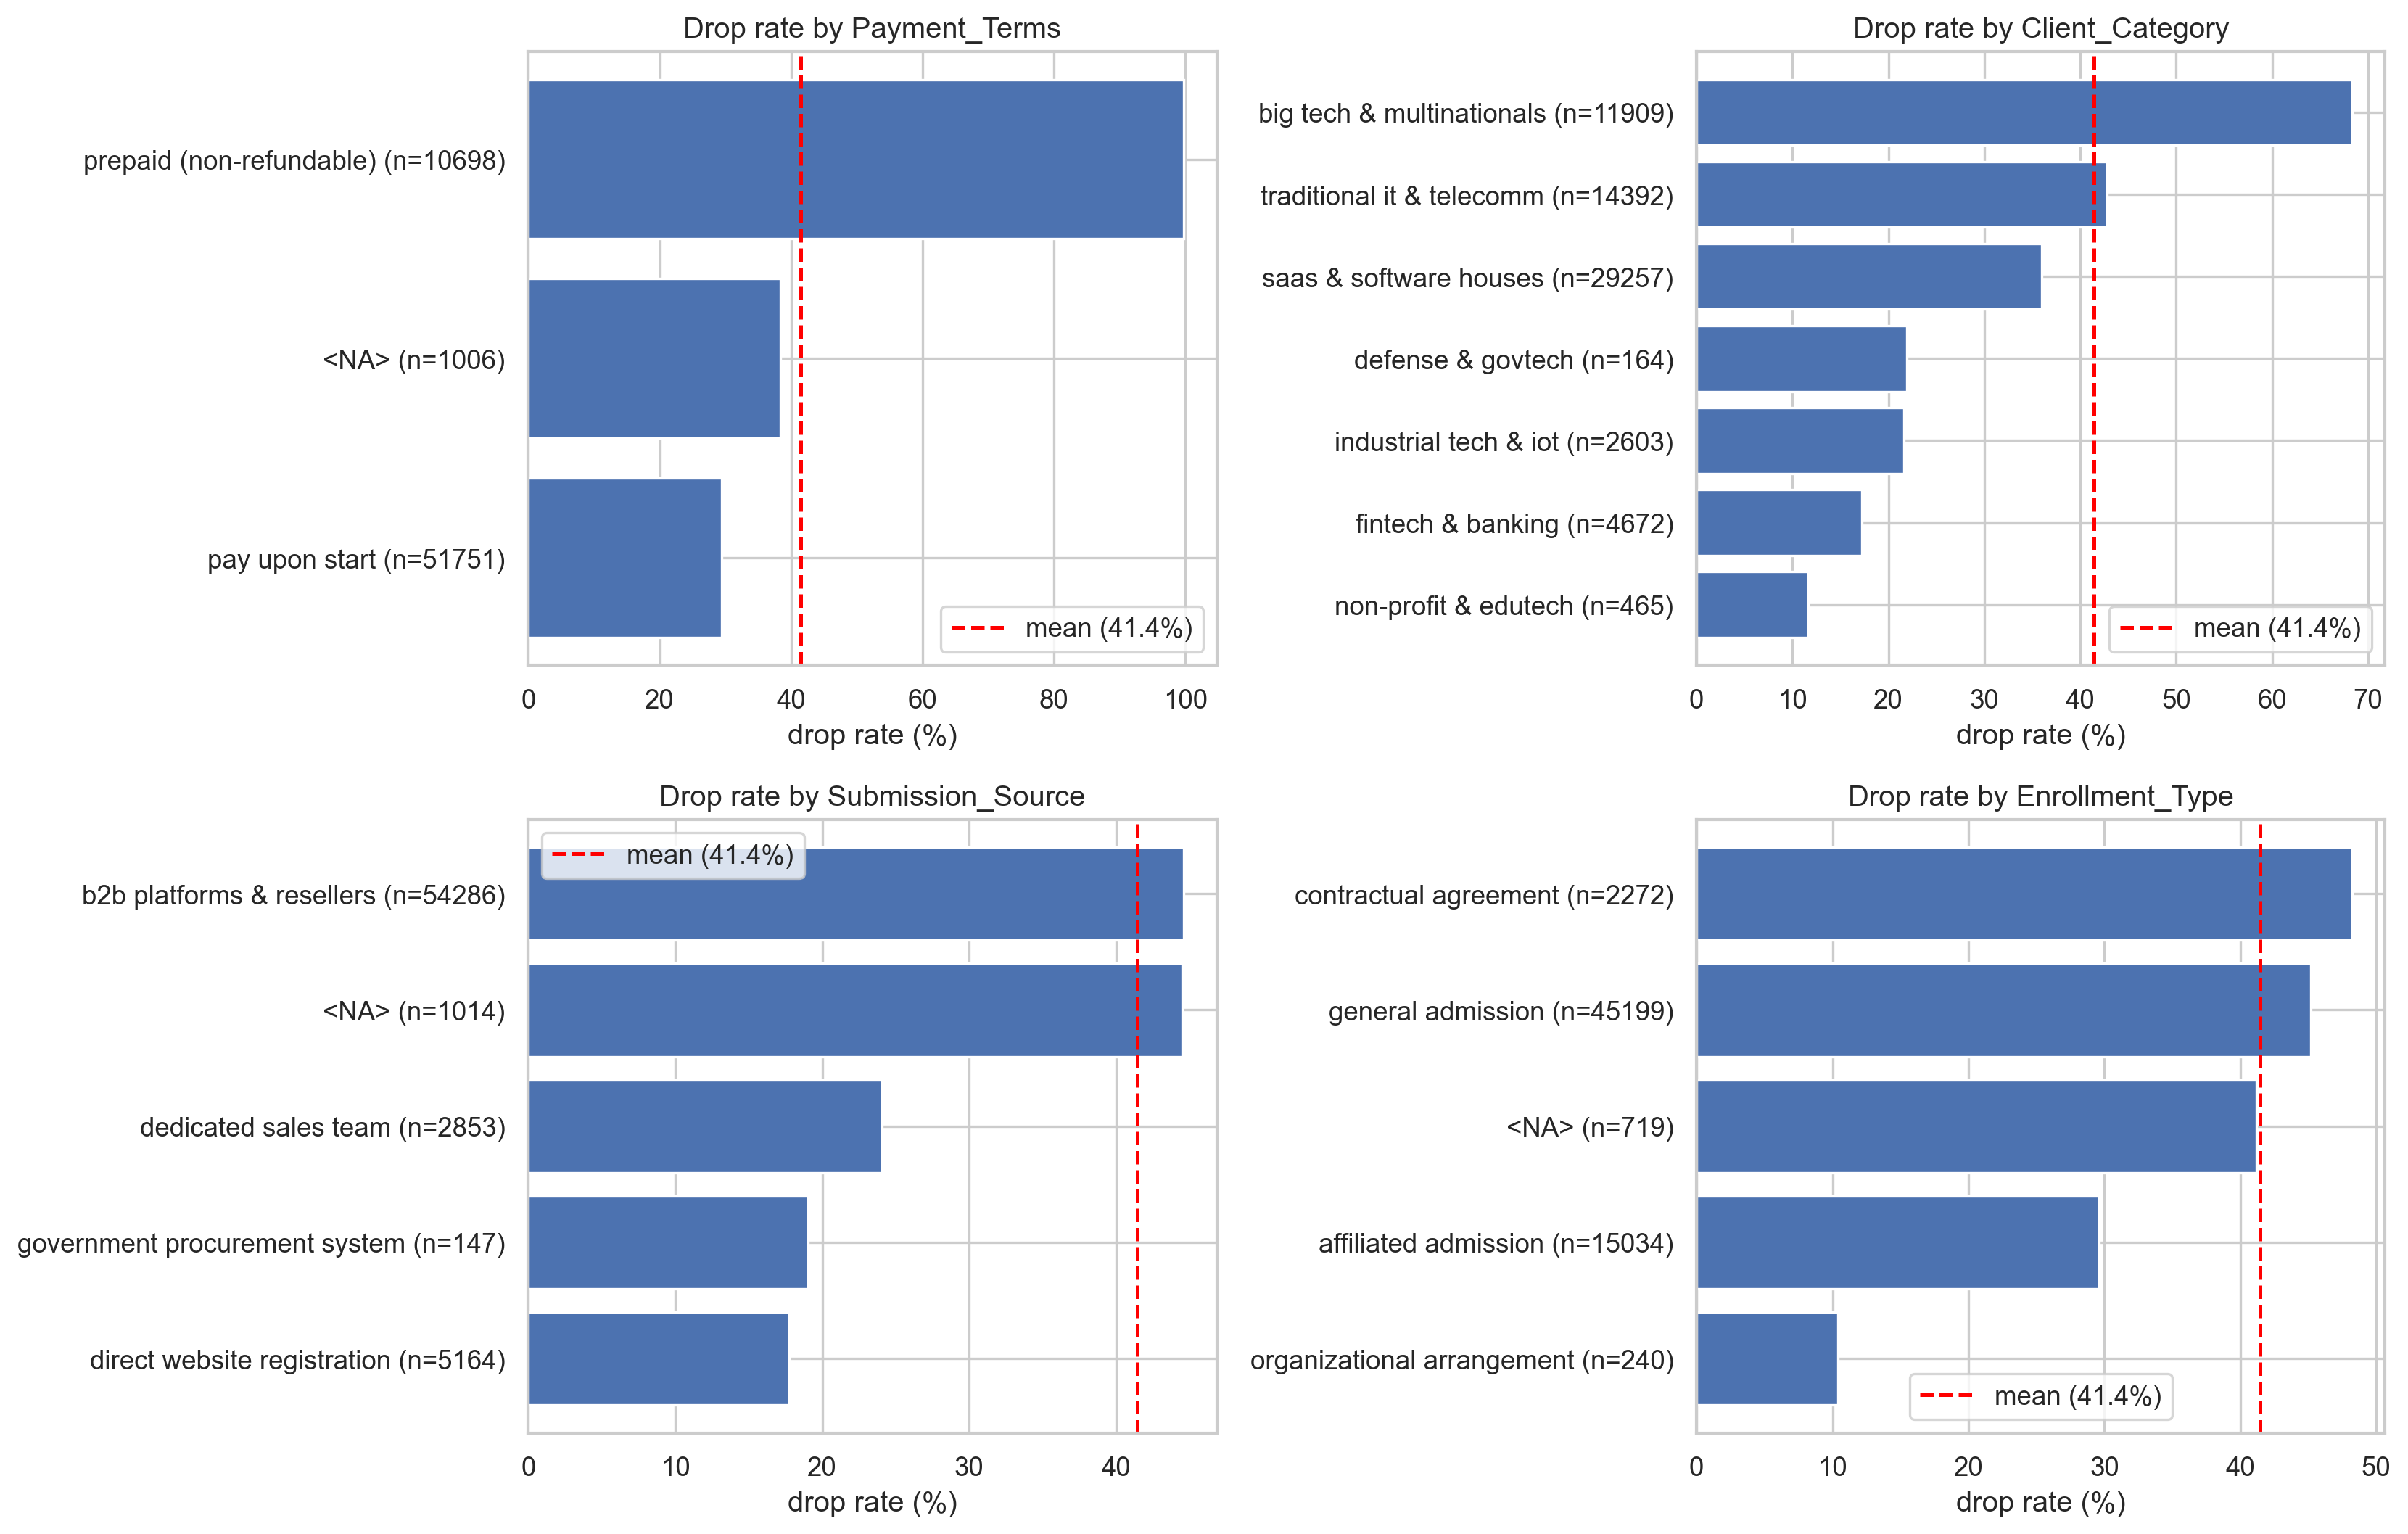

In [9]:
clean_train = normalize_cats(train_raw)


def plot_dropout_by_category(df, col, min_count=50, top_n=10, ax=None):
    stats = df.groupby(col, dropna=False)[TARGET].agg(drop_rate="mean", count="size")
    stats = (
        stats[stats["count"] >= min_count]
        .sort_values("count", ascending=False)
        .head(top_n)
        .sort_values("drop_rate")
    )
    labels = [f"{i} (n={int(r['count'])})" for i, r in stats.iterrows()]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    ax.barh(labels, stats["drop_rate"] * 100, color="#4c72b0")
    overall = df[TARGET].mean() * 100
    ax.axvline(overall, ls="--", color="red", label=f"mean ({overall:.1f}%)")
    ax.set_xlabel("drop rate (%)")
    ax.set_title(f"Drop rate by {col}")
    ax.legend()
    return stats


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_dropout_by_category(
    clean_train, "Payment_Terms", min_count=20, top_n=5, ax=axes[0, 0]
)
plot_dropout_by_category(
    clean_train, "Client_Category", min_count=100, top_n=8, ax=axes[0, 1]
)
plot_dropout_by_category(
    clean_train, "Submission_Source", min_count=100, top_n=6, ax=axes[1, 0]
)
plot_dropout_by_category(
    clean_train, "Enrollment_Type", min_count=100, top_n=6, ax=axes[1, 1]
)
plt.tight_layout()
plt.show()

**Findings.**

- **`Payment_Terms` is the single strongest categorical signal.** _Prepaid (non-refundable)_ orders drop far more often than _pay-on-start_ ones.
  - This is counter-intuitive (why cancel something you can't refund?) and strong enough that we flag it for a leakage plausibility assessment during interpretation (Section 9). We keep it, but watch it.
- **`Client_Category`**: big-tech / multinational segments drop above average; fintech/banking and industrial/IoT below.
- **`Submission_Source`**: direct-website and dedicated-sales orders are lower risk than B2B-platform / reseller traffic.
- **`Enrollment_Type`**: organisational / affiliated arrangements are lower risk than general or one-off contractual admissions.

By contrast, `Lanyard_Color` and `Welcome_Gift_Type` show no stable pattern and have no business reason to matter — candidates to drop as noise.


### Country, agent, and acquisition context

The categorical EDA suggests that dropout risk is not only attached to course logistics. Several business-context fields move together: country, agent, company presence, payment terms, and registration source.


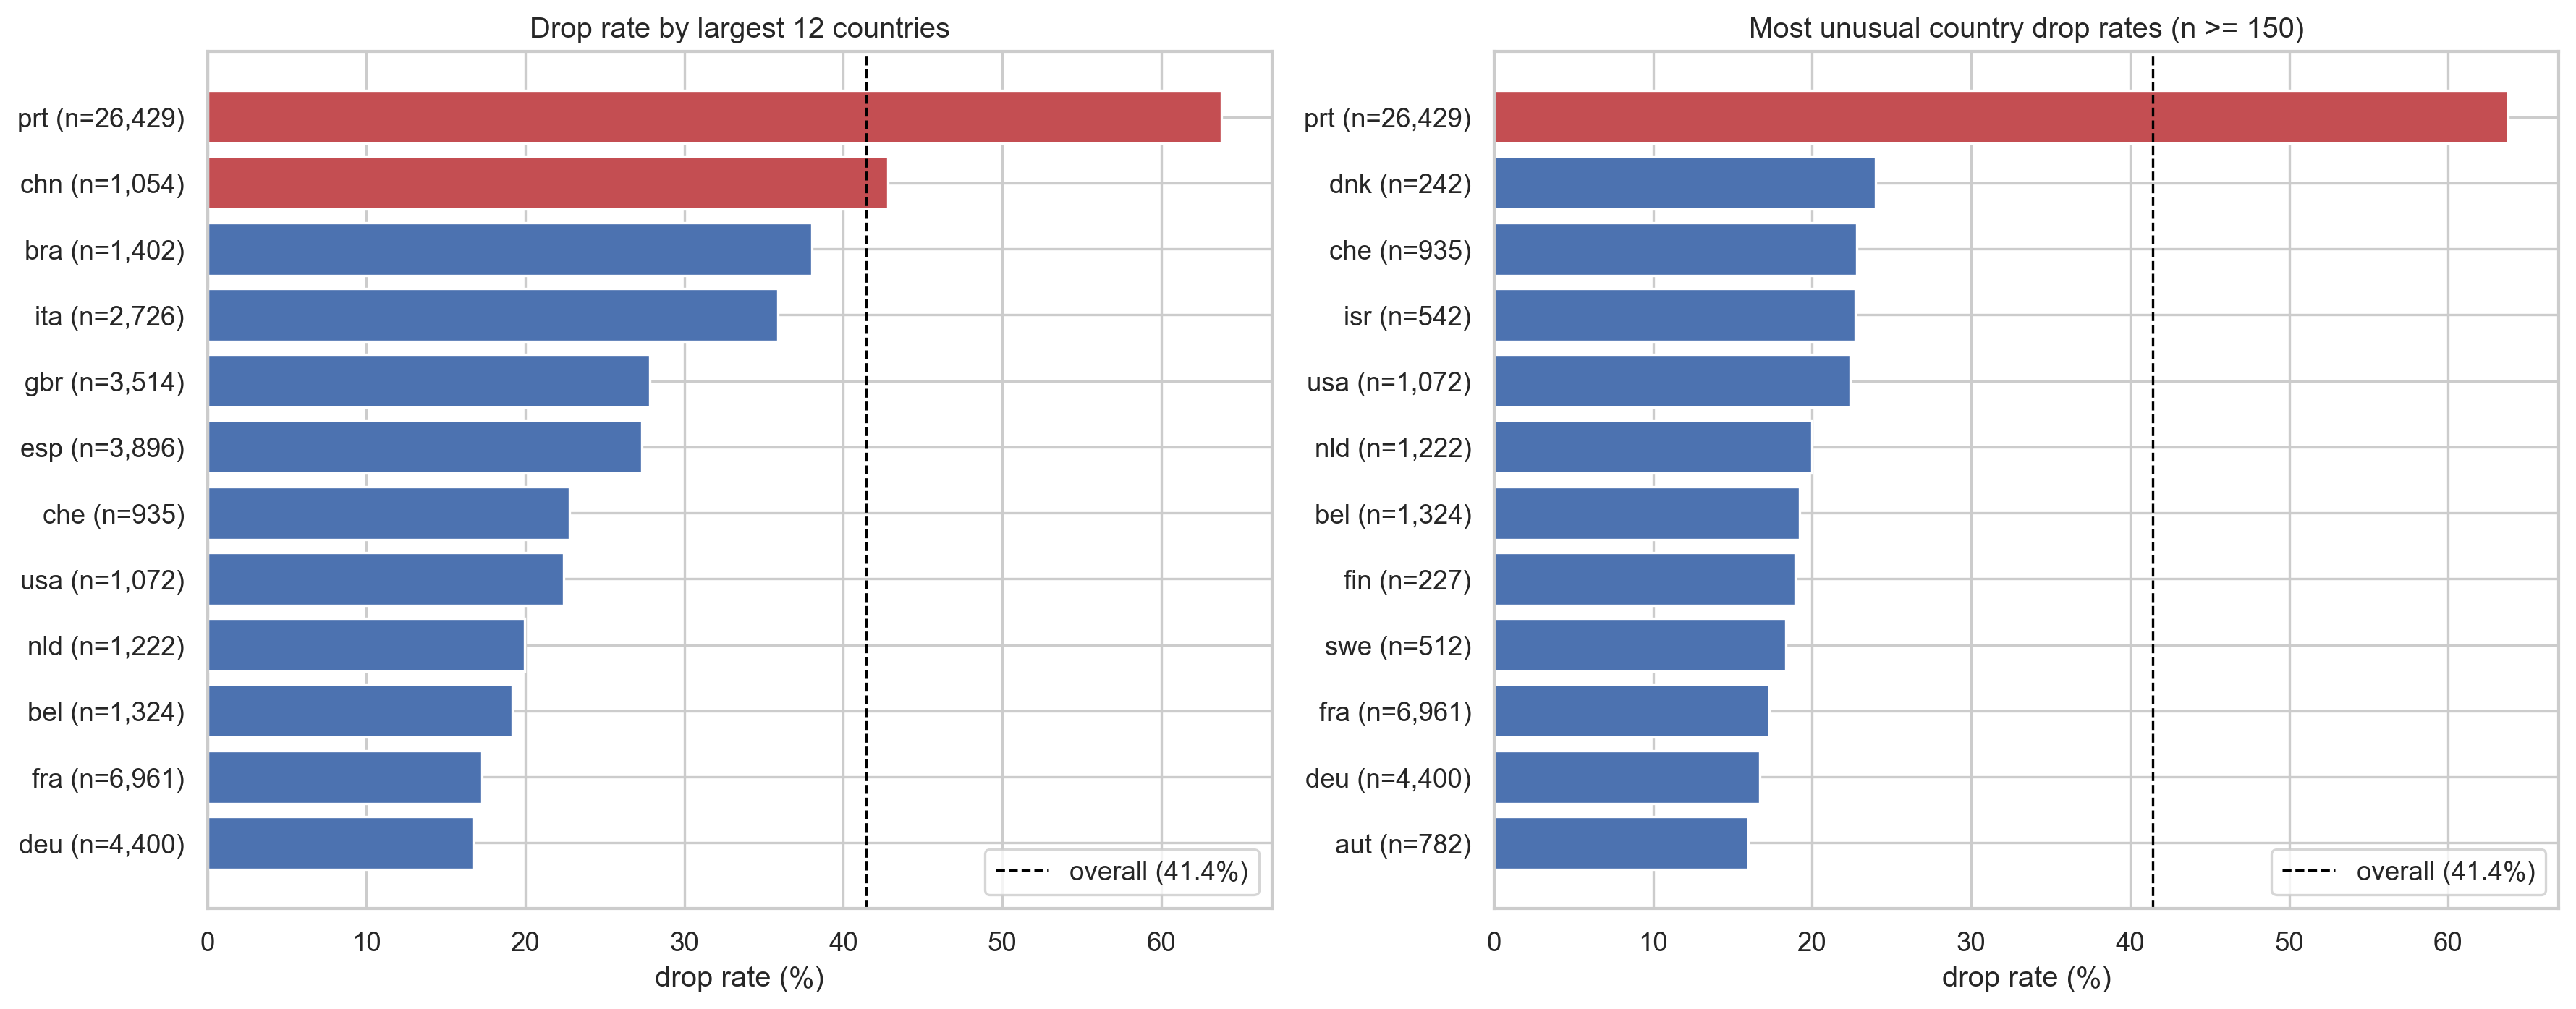

,count,drop_rate_pct,lift_pp
Origin_Country,,,
prt,26429,63.78,22.34
fra,6961,17.28,-24.16
deu,4400,16.70,-24.73
esp,3896,27.31,-14.13
gbr,3514,27.80,-13.64
ita,2726,35.88,-5.56
bra,1402,38.02,-3.42
bel,1324,19.18,-22.25
nld,1222,19.97,-21.47


In [10]:
country_min_n = 150
country_top_n = 12


overall_drop = clean_train[TARGET].mean()

country_stats = (
    clean_train
    .groupby("Origin_Country", dropna=False)[TARGET]
    .agg(count="size", drop_rate="mean")
    .assign(
        drop_rate_pct=lambda d: d["drop_rate"] * 100,
        lift_pp=lambda d: (d["drop_rate"] - overall_drop) * 100,
    )
)

top_by_size = country_stats.sort_values("count", ascending=False).head(country_top_n)

# Pick countries whose drop rate is farthest from the overall mean, after filtering tiny countries.
extreme_by_lift = (
    country_stats[
        country_stats["count"] >= country_min_n
    ]  # ignore countries with too few rows for a stable rate
    .iloc[
        lambda d: (
            d["lift_pp"].abs().sort_values(ascending=False).index.map(d.index.get_loc)
        )
    ]  # sort by distance from the overall drop rate
    .head(country_top_n)
)


def plot_country_dropout(stats, title, ax):
    stats = stats.sort_values("drop_rate_pct")
    labels = [
        f"{idx if pd.notna(idx) else '<missing>'} (n={int(row['count']):,})"
        for idx, row in stats.iterrows()
    ]
    colors = np.where(stats["lift_pp"] >= 0, "#c44e52", "#4c72b0")

    ax.barh(labels, stats["drop_rate_pct"], color=colors)
    ax.axvline(
        overall_drop * 100,
        ls="--",
        color="black",
        lw=1,
        label=f"overall ({overall_drop * 100:.1f}%)",
    )
    ax.set_xlabel("drop rate (%)")
    ax.set_title(title)
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_country_dropout(
    top_by_size,
    f"Drop rate by largest {country_top_n} countries",
    axes[0],
)

plot_country_dropout(
    extreme_by_lift,
    f"Most unusual country drop rates (n >= {country_min_n})",
    axes[1],
)

plt.tight_layout()
plt.show()

display(
    country_stats
    .sort_values("count", ascending=False)
    .head(country_top_n)[["count", "drop_rate_pct", "lift_pp"]]
    .round(2)
)

`Origin_Country` is a major categorical signal, and Portugal is the clearest example because it is both very common and far above the overall dropout rate. This is not a rare-country artefact: the large-country plot and the extreme-country plot tell the same story.

Still, country alone is not the full explanation. A high-risk country can also concentrate particular payment terms, submission sources, client segments, or agents. We therefore treat country as a useful context signal, not as a causal explanation by itself.


In [11]:
is_portugal = clean_train["Origin_Country"].eq("prt").fillna(False).to_numpy(dtype=bool)
country_group = np.where(is_portugal, "Portugal", "Other countries")

portugal_summary = (
    clean_train
    .assign(country_group=country_group)
    .groupby("country_group")[TARGET]
    .agg(count="size", drop_rate="mean")
    .assign(drop_rate_pct=lambda d: d["drop_rate"] * 100)
)

dropper_country_mix = (
    pd
    .crosstab(
        clean_train[TARGET].map({0: "completed", 1: "dropped"}),
        country_group,
        normalize="index",
    )
    .mul(100)
    .round(1)
)

display(portugal_summary.round(3))
display(dropper_country_mix)

,count,drop_rate,drop_rate_pct
country_group,,,
Other countries,37035,0.255,25.498
Portugal,26429,0.638,63.778


col_0,Other countries,Portugal
Dropped_Course,,
completed,74.2,25.8
dropped,35.9,64.1


In [12]:
portugal_slices = []
for col in ["Payment_Terms", "Submission_Source", "Client_Category"]:
    top_levels = (
        clean_train[is_portugal]
        .groupby(col, dropna=False)[TARGET]
        .agg(count="size", drop_rate="mean")
        .sort_values("count", ascending=False)
        .head(5)
        .reset_index()
        .rename(columns={col: "level"})
    )
    top_levels.insert(0, "field", col)
    portugal_slices.append(top_levels)

display(
    pd
    .concat(portugal_slices, ignore_index=True)
    .assign(drop_rate_pct=lambda d: d["drop_rate"] * 100)[
        ["field", "level", "count", "drop_rate_pct"]
    ]
    .round(2)
)

,field,level,count,drop_rate_pct
0,Payment_Terms,pay upon start,15554,39.58
1,Payment_Terms,prepaid (non-refundable),10482,99.85
2,Payment_Terms,<NA>,392,59.18
3,Payment_Terms,refundable deposit,1,100.00
4,Submission_Source,b2b platforms & resellers,21790,70.52
5,Submission_Source,direct website registration,2197,25.72
6,Submission_Source,dedicated sales team,1993,31.71
7,Submission_Source,<NA>,431,67.29
8,Submission_Source,government procurement system,18,16.67
9,Client_Category,big tech & multinationals,9284,85.65


The Portugal slice shows why the country effect should not be read too literally. Portugal is high-risk overall, but the risk is concentrated in specific acquisition patterns, especially payment terms and B2B/reseller traffic. Some Portugal subgroups are much closer to ordinary dropout rates.

The identifier columns carry signal too. `Agent_ID` and `Company_ID` are labels, not numbers. Frequent agents have very different drop rates, and _having_ a company id lowers risk, so identity is predictive and we must keep it without exploding the feature space (Section 5.2).


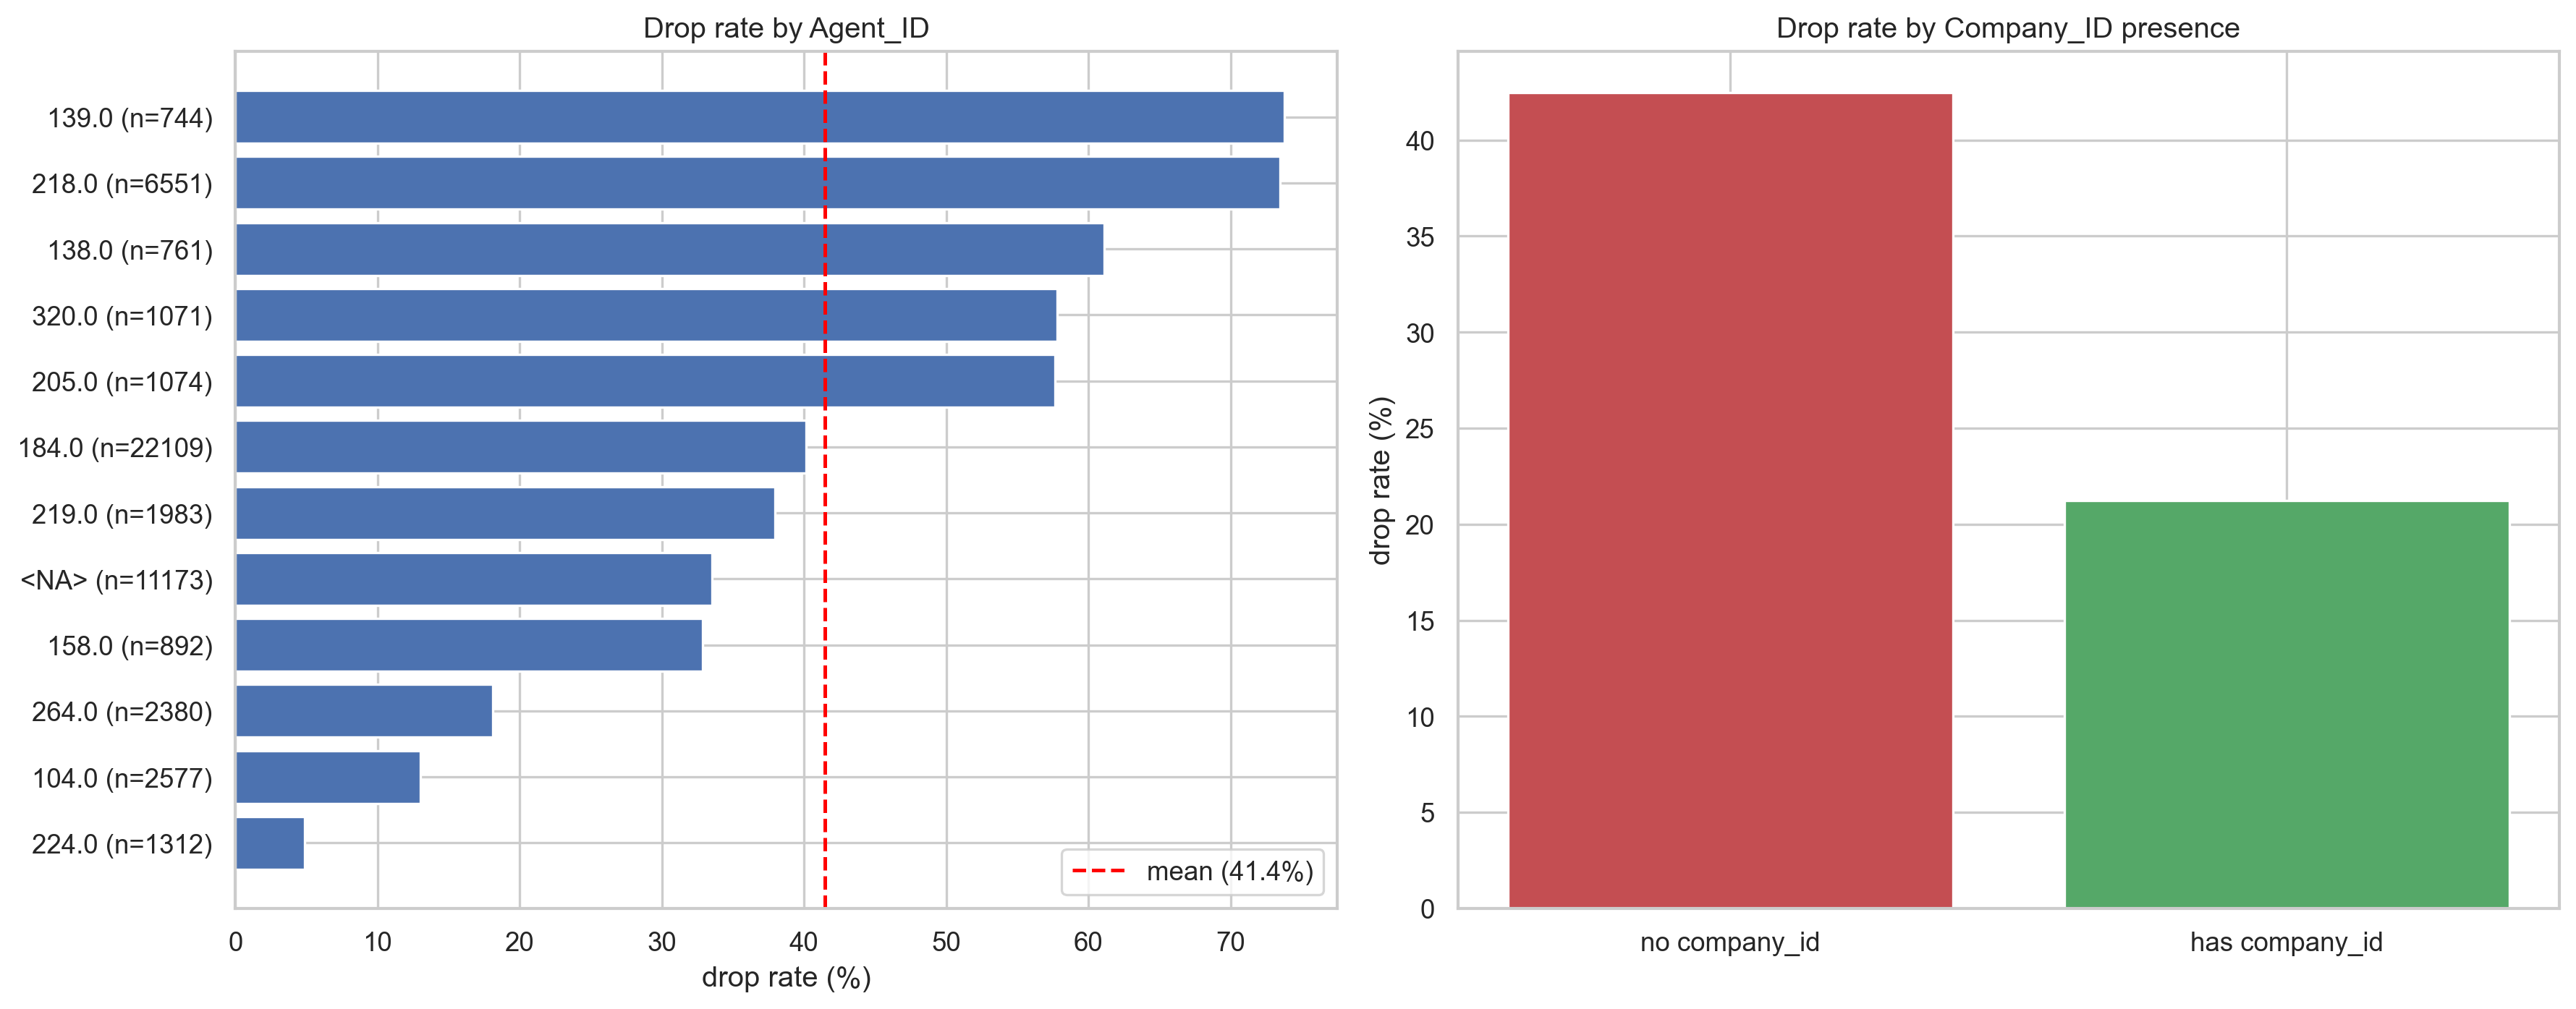

,count,drop_rate
no company_id,60344,0.424848
has company_id,3120,0.212179


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_dropout_by_category(clean_train, "Agent_ID", min_count=150, top_n=12, ax=axes[0])
company_presence = train_raw.groupby(train_raw["Company_ID"].notna())[TARGET].agg(
    count="size", drop_rate="mean"
)
company_presence.index = ["no company_id", "has company_id"]
axes[1].bar(
    company_presence.index,
    company_presence["drop_rate"] * 100,
    color=["#c44e52", "#55a868"],
)
axes[1].set_ylabel("drop rate (%)")
axes[1].set_title("Drop rate by Company_ID presence")
plt.tight_layout()
plt.show()
display(company_presence)

The agent plot is useful, but it raises a fair concern: risky agents may simply be agents assigned to risky countries or channels. This is not classical numeric multicollinearity; it is overlapping categorical signal. We check it directly by asking how well `Agent_ID` predicts `Origin_Country`.


In [14]:
agent_country_pairs = clean_train[["Agent_ID", "Origin_Country"]].dropna()

agent_country = agent_country_pairs.groupby("Agent_ID")["Origin_Country"].agg(
    count="size",
    countries="nunique",
    top_country=lambda s: s.value_counts().idxmax(),
    top_country_share=lambda s: s.value_counts(normalize=True).iloc[0],
)

country_tr, country_va = train_test_split(
    agent_country_pairs, test_size=0.25, random_state=SEED
)
majority_country = country_tr["Origin_Country"].mode().iat[0]
agent_country_map = country_tr.groupby("Agent_ID")["Origin_Country"].agg(
    lambda s: s.value_counts().idxmax()
)
agent_country_pred = (
    country_va["Agent_ID"].map(agent_country_map).fillna(majority_country)
)

display(
    pd.DataFrame({
        "check": ["majority country baseline", "agent modal country"],
        "accuracy": [
            country_va["Origin_Country"].eq(majority_country).mean(),
            agent_country_pred.eq(country_va["Origin_Country"]).mean(),
        ],
    }).round(3)
)

display(
    agent_country
    .sort_values("count", ascending=False)
    .head(12)
    .assign(top_country_share_pct=lambda d: d["top_country_share"] * 100)[
        ["count", "countries", "top_country", "top_country_share_pct"]
    ]
    .round(1)
)

,check,accuracy
0,majority country baseline,0.391
1,agent modal country,0.421


,count,countries,top_country,top_country_share_pct
Agent_ID,,,,
184.0,21923,135,fra,14.8
218.0,6488,30,prt,84.0
104.0,2552,65,prt,23.4
264.0,2355,69,prt,22.0
219.0,1967,17,prt,58.6
224.0,1299,26,fra,63.3
205.0,1065,15,prt,71.9
320.0,1061,46,prt,69.1
158.0,884,39,prt,43.6


The overlap is real but incomplete. Some agents are heavily country-focused, especially around Portugal, while the largest agent serves many countries. So country does not fully explain agent behavior, and agent does not fully explain country behavior. We keep both signals, but encode them compactly later instead of one-hotting hundreds of levels.


## 3.5 Numeric features: summary, correlation, and suspects

For the numeric columns we tabulate central tendency, spread, skew, and correlation with the target, then look at the correlation structure between features.


In [15]:
ID_LIKE = ["Client_ID", "Agent_ID", "Company_ID"]
num_cols = [
    c
    for c in train_raw.select_dtypes(include=["int64", "float64"]).columns
    if c not in ID_LIKE + [TARGET]
]


def numeric_summary(df, cols):
    rows = []
    for c in cols:
        s = df[c]
        rows.append({
            "column": c,
            "missing_%": round(s.isna().mean() * 100, 1),
            "corr_target": round(s.corr(df[TARGET]), 3),
            "mean": round(s.mean(), 2),
            "median": round(s.median(), 2),
            "std": round(s.std(), 2),
            "min": round(s.min(), 2),
            "max": round(s.max(), 2),
            "skew": round(s.skew(), 2),
        })
    return pd.DataFrame(rows).sort_values("corr_target", key=abs, ascending=False)


display(numeric_summary(train_raw, num_cols))

,column,missing_%,corr_target,mean,median,std,min,max,skew
5,Registration_Days_Before,4.2,0.351,102.89,65.0,109.18,0.0,629.0,1.50
8,Pre_Course_Supports_Tickets,0.0,-0.301,0.51,0.0,0.76,0.0,5.0,1.47
6,Prev_Course_Dropouts,0.0,0.199,0.10,0.0,0.45,0.0,21.0,15.70
11,Registration_Changes,0.0,-0.148,0.18,0.0,0.59,0.0,21.0,7.36
9,Physical_Course_Kits,1.6,-0.138,0.03,0.0,0.16,0.0,3.0,6.00
10,Waiting_List_Days,0.0,0.068,3.98,0.0,23.20,0.0,391.0,9.26
12,Returning_Client,0.0,-0.059,0.03,0.0,0.16,0.0,1.0,5.82
0,Professionals_Count,0.0,0.057,1.84,2.0,0.51,0.0,4.0,-0.47
7,Prev_Course_Attended,0.0,-0.052,0.12,0.0,1.54,0.0,61.0,21.96
4,Theory_Hours,0.0,0.045,2.16,2.0,1.47,0.0,41.0,3.35


The `max` column already exposes the corrupted values: `Students_Count` maxes at 9999 and `Practical_Hours` at 10000, with a negative minimum. We handle these in Section 4. First, the correlation picture.


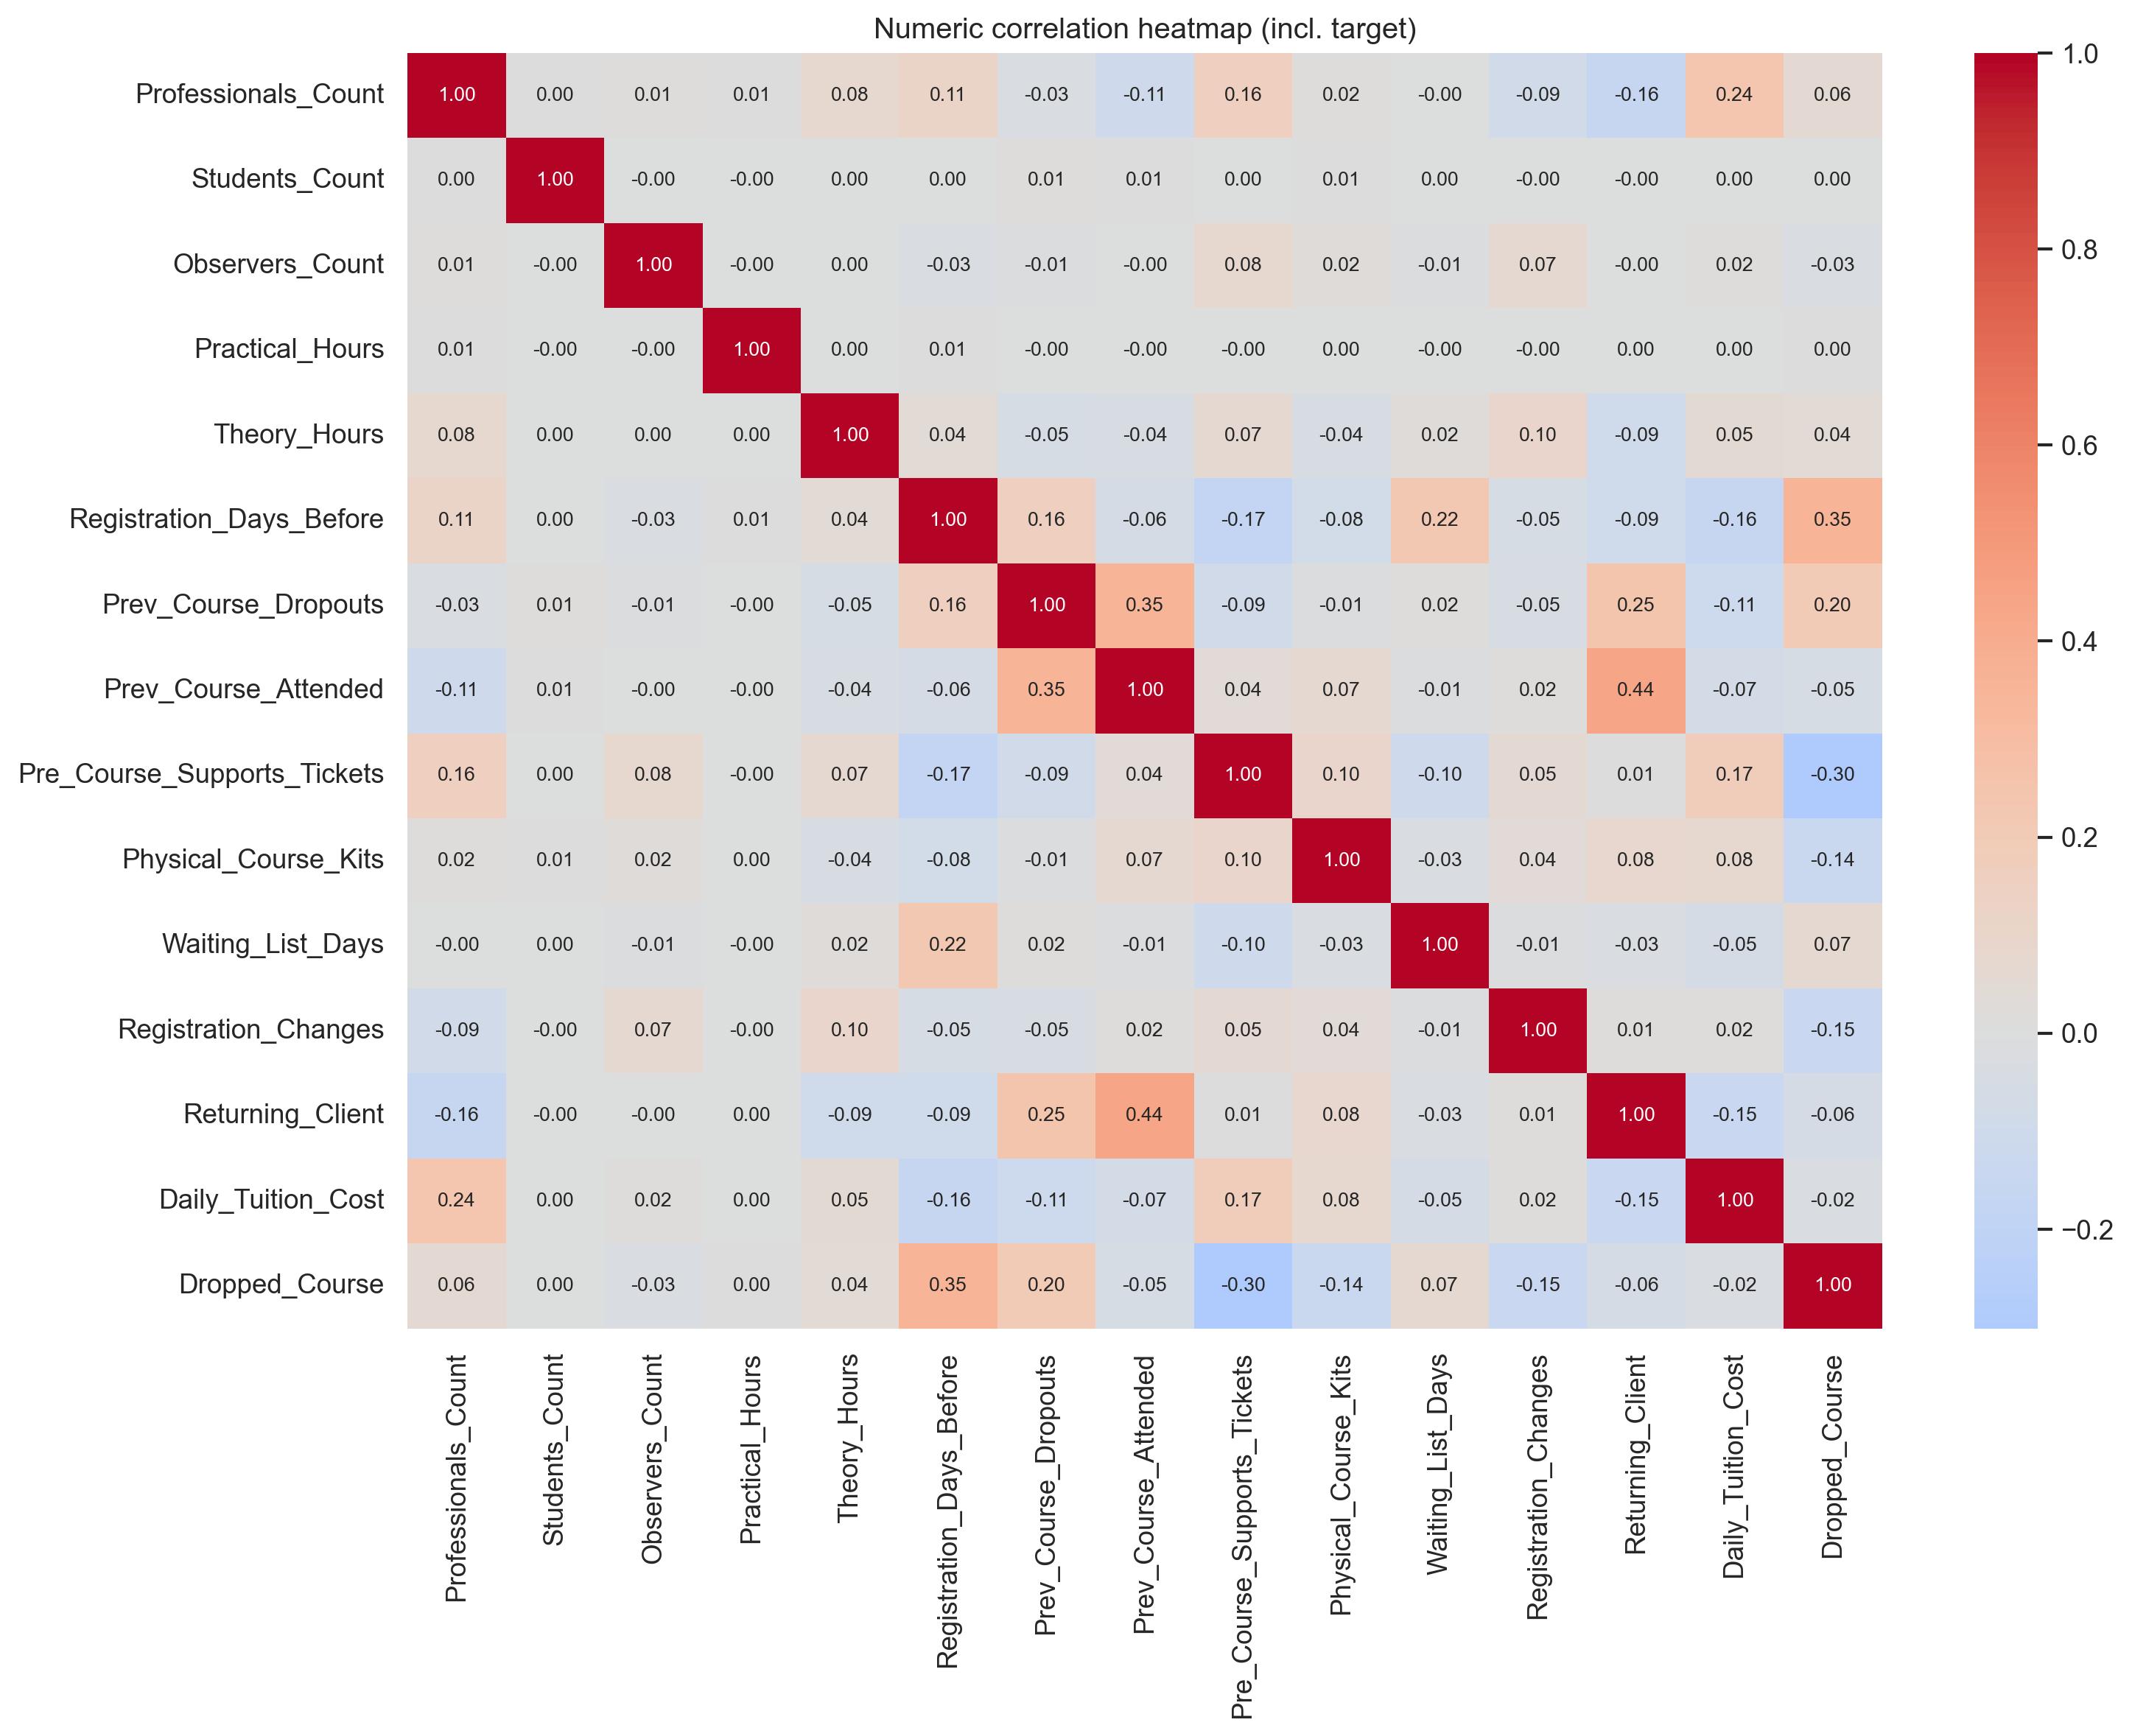

In [16]:
corr = train_raw[num_cols + [TARGET]].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f", annot_kws={"size": 8}, cmap="coolwarm", center=0
)
plt.title("Numeric correlation heatmap (incl. target)")
plt.tight_layout()
plt.show()

**Reading the heatmap.** No single raw numeric feature correlates strongly with the target. That is consistent with **non-linear / interaction-driven** signal, which we test later by comparing linear baselines with gradient-boosted trees. Inter-feature correlations are mild, so there is no severe multicollinearity forcing us to drop columns; the dimensionality problem lives in the _categoricals_, not here (Section 5.2).


## 3.6 Numeric drop-rate profiles

Binning a couple of the more predictive numeric features shows _how_ risk moves with them (not just whether they correlate linearly).


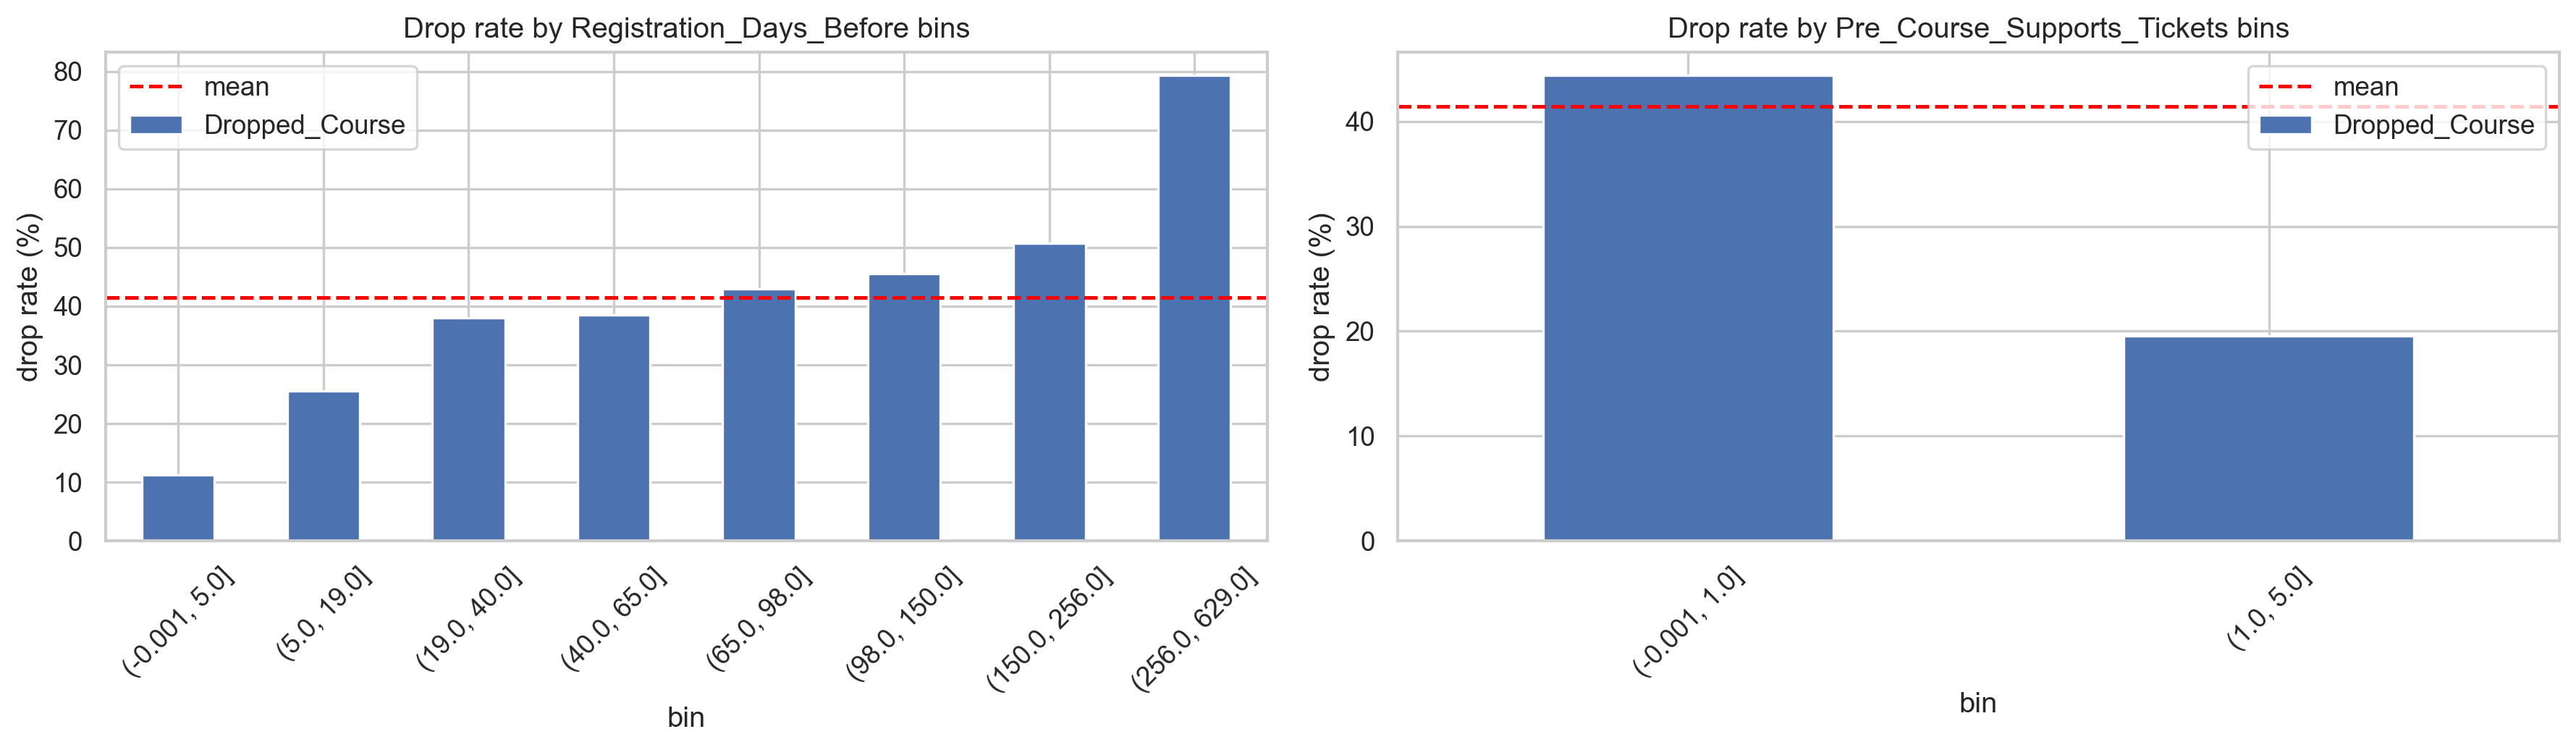

In [17]:
def plot_dropout_by_bins(df, col, bins=8, ax=None):
    tmp = df[[col, TARGET]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=bins, duplicates="drop")
    stats = tmp.groupby("bin", observed=True)[TARGET].mean().mul(100)
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    stats.plot.bar(ax=ax, color="#4c72b0")
    ax.axhline(df[TARGET].mean() * 100, ls="--", color="red", label="mean")
    ax.set_ylabel("drop rate (%)")
    ax.set_title(f"Drop rate by {col} bins")
    ax.legend()
    ax.tick_params(axis="x", labelrotation=45)
    return stats


fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_dropout_by_bins(train_raw, "Registration_Days_Before", bins=8, ax=axes[0])
plot_dropout_by_bins(train_raw, "Pre_Course_Supports_Tickets", bins=6, ax=axes[1])
plt.tight_layout()
plt.show()

- **`Registration_Days_Before`**: the earlier a group registers relative to the
  course, the more likely it is to drop — plausibly because plans change over a
  longer horizon.
- **`Pre_Course_Supports_Tickets`**: more pre-course engagement is associated
  with _lower_ dropping — a group that is actively preparing is committed.

### 3.7. **EDA takeaways carried forward:**

time structure (headline), payment terms, registration timing, country/agent/company context, client segment & channel, and support engagement are the strongest visible signals.


# 4. Missing-value handling & outlier analysis

Guided by the EDA, we now fix the corrupted values and decide the imputation policy. Both are applied _inside_ the feature builder (Section 5) so train and test are transformed identically.


## 4.1 Outliers: identify, justify, cap

We look for values that are physically impossible or absurdly far from the bulk.


In [18]:
def sus_report(df, cols, max_mult=10):
    out = []
    for c in cols:
        s = df[c].dropna()
        q99 = s.quantile(0.99)
        iqr = s.quantile(0.75) - s.quantile(0.25)
        scale = max(q99, iqr, 1.0)
        why = []
        if s.min() < 0:
            why.append("negative values")
        if s.max() > max_mult * scale:
            why.append(f"max={s.max():g} >> q99={q99:g}")
        if why:
            out.append({
                "column": c,
                "min": s.min(),
                "max": s.max(),
                "q99": round(q99, 1),
                "why": "; ".join(why),
            })
    return pd.DataFrame(out)


print("Suspect columns — TRAIN")
display(sus_report(train_raw, num_cols))
print("Suspect columns — TEST")
display(sus_report(test_raw, num_cols))

Suspect columns — TRAIN


,column,min,max,q99,why
0,Students_Count,0.0,9999.0,2.0,max=9999 >> q99=2
1,Practical_Hours,-5.0,10000.0,3.0,negative values; max=10000 >> q99=3
2,Prev_Course_Dropouts,0.0,21.0,1.0,max=21 >> q99=1
3,Prev_Course_Attended,0.0,61.0,3.0,max=61 >> q99=3
4,Registration_Changes,0.0,21.0,2.0,max=21 >> q99=2
5,Daily_Tuition_Cost,0.0,5400.0,209.7,max=5400 >> q99=209.7


Suspect columns — TEST


,column,min,max,q99,why
0,Students_Count,0.0,9999.0,2.0,max=9999 >> q99=2
1,Practical_Hours,-5.0,10000.0,2.0,negative values; max=10000 >> q99=2
2,Prev_Course_Attended,0.0,72.0,3.0,max=72 >> q99=3
3,Waiting_List_Days,0.0,183.0,0.0,max=183 >> q99=0


The test set introduces **no new kinds** of corruption, so caps learned from domain reasoning on train transfer safely. We also inspect the relationship between two historical counters:


In [19]:
impossible = train_raw[
    train_raw["Prev_Course_Dropouts"] > train_raw["Prev_Course_Attended"]
]
print(f"rows where historical dropouts exceed historical attended: {len(impossible)}")

rows where historical dropouts exceed historical attended: 4985


**Decisions and justification.**
We **clip (winsorize) rather than drop rows** for fields with clear placeholder or physically impossible values: the _other_ fields in those rows are still valid and informative, and clipping keeps train and test aligned.

The 4,985 rows where historical dropouts exceed historical attended require a different interpretation. Section 5 uses these columns to build `prev_drop_rate`, so this check means we should not present that engineered value as a literal probability. Instead, we treat it as a smoothed **dropout-intensity** signal: high values indicate heavier prior dropout history relative to prior attendance, but values above 1 can occur if the two counters describe different historical windows or independent aggregates.

For that reason, we keep both raw counters and the ratio-like signal, but we do **not** force the ratio into `[0, 1]` and do **not** drop the affected rows. Other flagged count columns (`Prev_Course_Dropouts`, `Prev_Course_Attended`, `Registration_Changes`, and test-side `Waiting_List_Days`) are heavy-tailed but plausible, so we leave them uncapped unless a concrete domain rule gives a cap. The table quantifies the clipped rows; the figure shows the distribution before and after each cap.


,column,raw_train_min,raw_train_max,problem,action,train_rows_affected,test_rows_affected,reason
0,Students_Count,0.0,9999.0,9999 placeholder,clip to <= 10,55,12,course groups are single-/low-double-digit
1,Practical_Hours,-5.0,10000.0,negative values and 10000,"clip to [0, 12]",121,23,course hours cannot be negative or five-digit
2,Daily_Tuition_Cost,0.0,5400.0,5400 value,clip to <= 600,1,0,about 30x the typical daily rate


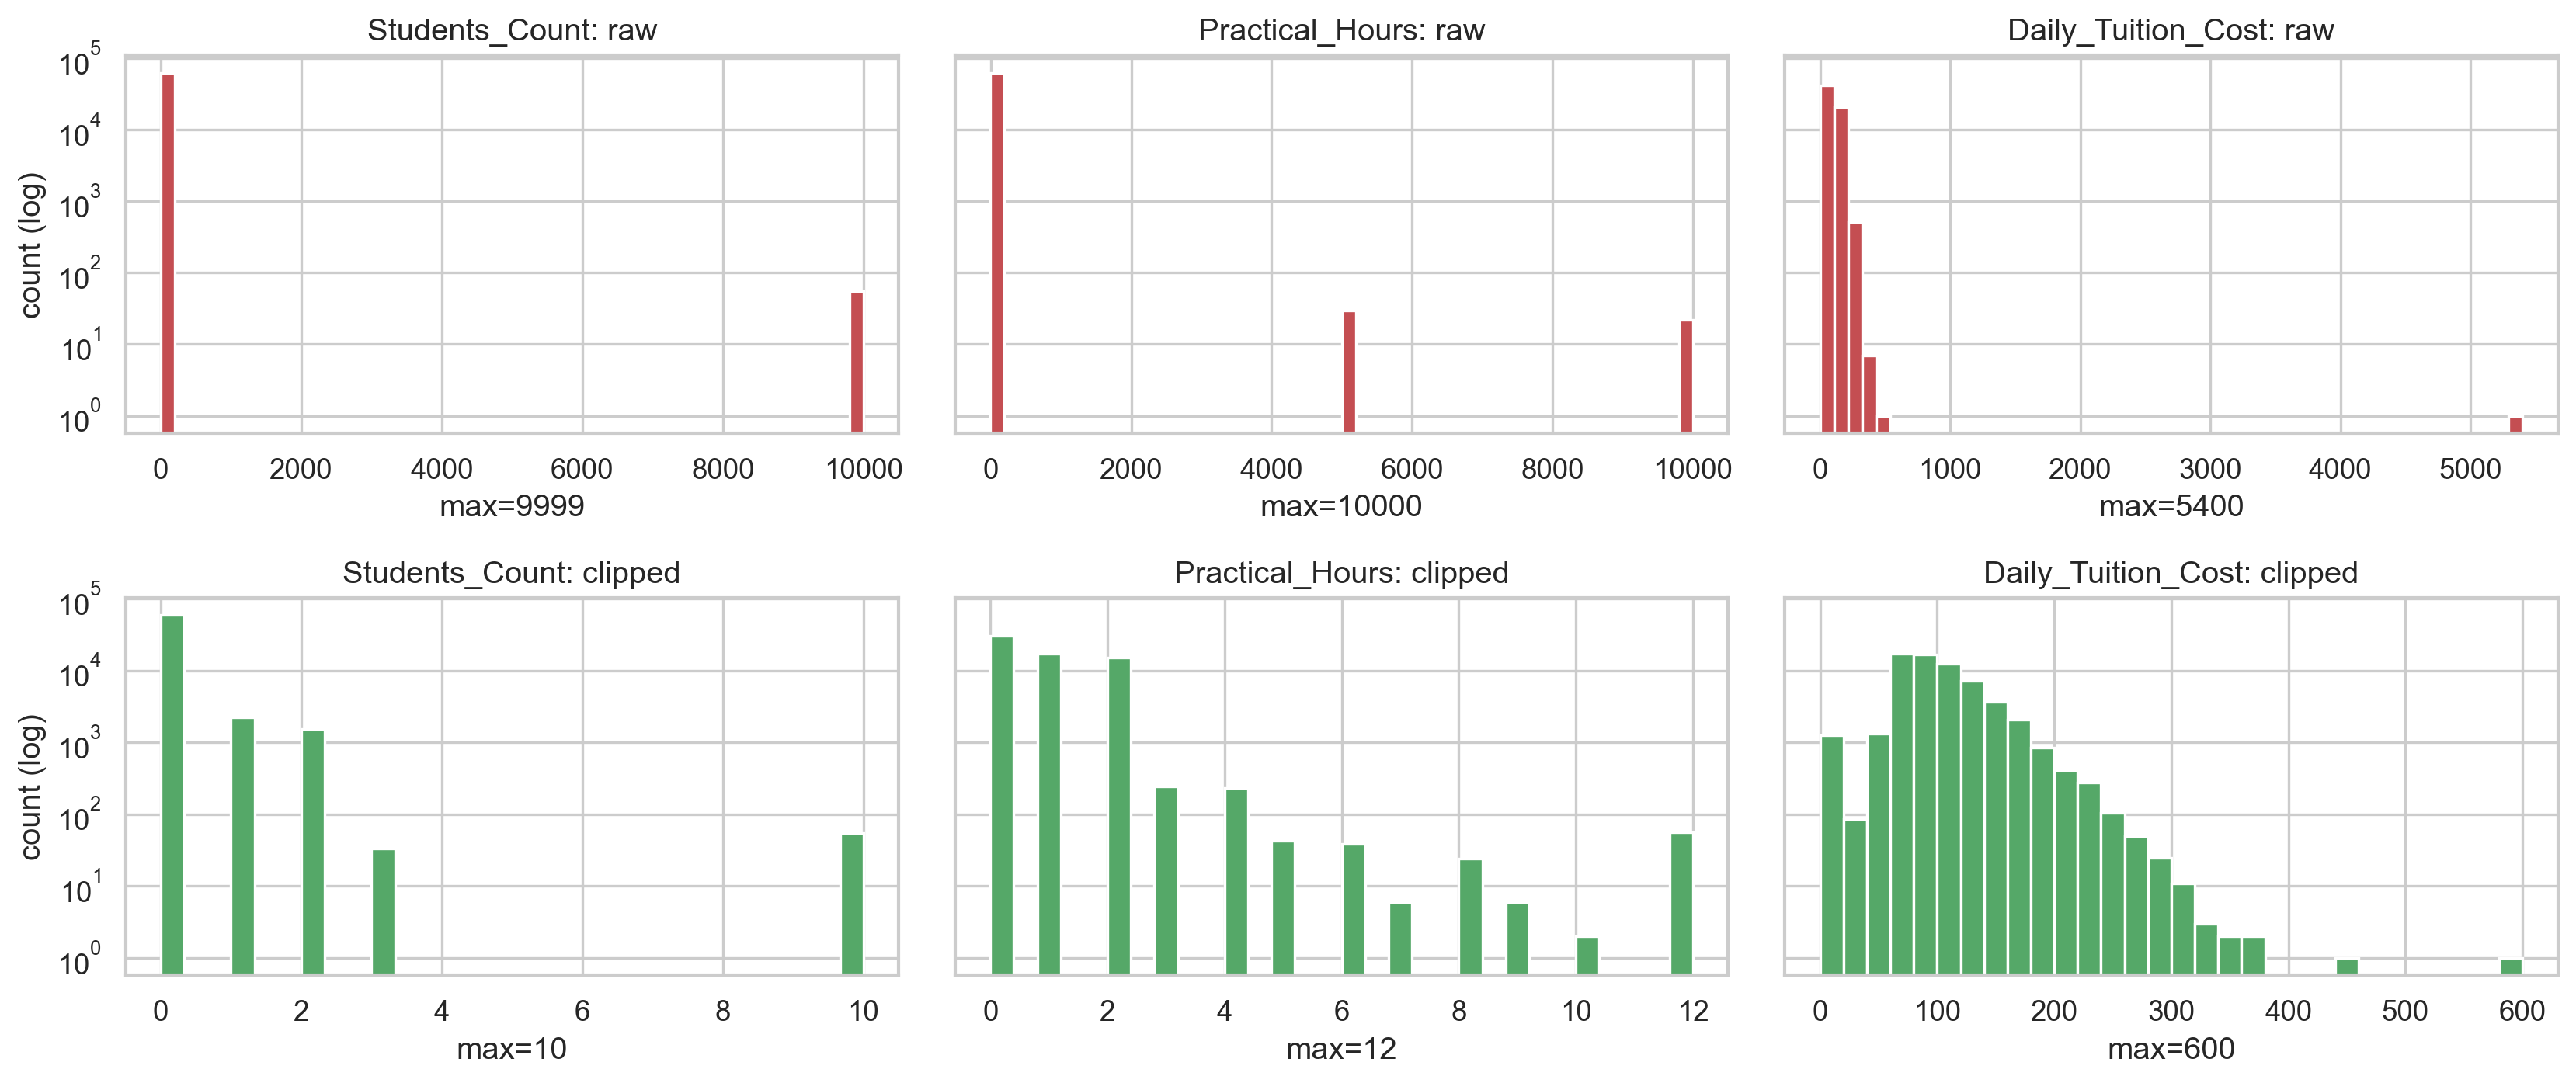

In [20]:
CAP_RULES = {
    "Students_Count": {
        "lower": None,
        "upper": 10,
        "problem": "9999 placeholder",
        "reason": "course groups are single-/low-double-digit",
    },
    "Practical_Hours": {
        "lower": 0,
        "upper": 12,
        "problem": "negative values and 10000",
        "reason": "course hours cannot be negative or five-digit",
    },
    "Daily_Tuition_Cost": {
        "lower": None,
        "upper": 600,
        "problem": "5400 value",
        "reason": "about 30x the typical daily rate",
    },
}


def apply_cap(s, lower=None, upper=None):
    if lower is not None:
        s = s.clip(lower=lower)
    if upper is not None:
        s = s.clip(upper=upper)
    return s


cap_rows = []
for col, rule in CAP_RULES.items():
    lo, hi = rule["lower"], rule["upper"]
    train_changed = (
        train_raw[col].notna() & apply_cap(train_raw[col], lo, hi).ne(train_raw[col])
    ).sum()
    test_changed = (
        test_raw[col].notna() & apply_cap(test_raw[col], lo, hi).ne(test_raw[col])
    ).sum()
    action = f"clip to [{lo}, {hi}]" if lo is not None else f"clip to <= {hi}"
    cap_rows.append({
        "column": col,
        "raw_train_min": train_raw[col].min(),
        "raw_train_max": train_raw[col].max(),
        "problem": rule["problem"],
        "action": action,
        "train_rows_affected": int(train_changed),
        "test_rows_affected": int(test_changed),
        "reason": rule["reason"],
    })

display(pd.DataFrame(cap_rows))

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey="row")
for j, (col, rule) in enumerate(CAP_RULES.items()):
    before = train_raw[col].dropna()
    after = apply_cap(train_raw[col], rule["lower"], rule["upper"]).dropna()

    axes[0, j].hist(before, bins=50, color="#c44e52")
    axes[0, j].set_yscale("log")
    axes[0, j].set_title(f"{col}: raw")
    axes[0, j].set_xlabel(f"max={before.max():g}")

    axes[1, j].hist(after, bins=30, color="#55a868")
    axes[1, j].set_yscale("log")
    axes[1, j].set_title(f"{col}: clipped")
    axes[1, j].set_xlabel(f"max={after.max():g}")

axes[0, 0].set_ylabel("count (log)")
axes[1, 0].set_ylabel("count (log)")
plt.tight_layout()
plt.show()

## 4.2 Missing-value policy

Different column types get different treatment, each justified:

- **Categoricals** → keep an explicit `"missing"` level. For tree models,
  "missing" is just another category the model can split on; the EDA showed
  missingness is itself predictive, so we must not erase it.
- **High-cardinality IDs** (`Agent_ID`, `Company_ID`) → represented via
  **presence flags** and **frequency encoding** (Section 5.2), not imputed.
- **Numerics** → the gradient-boosting libraries we use (LightGBM, XGBoost,
  CatBoost) handle `NaN` natively by learning a default split direction, which
  is strictly more informative than median-filling. We therefore **pass numeric
  NaNs through** to the models rather than imputing them, and only compute
  fill-values inside engineered _ratios_ to avoid divide-by-zero.

This is a deliberate change from the first modeling attempt, which median-imputed everything for a one-hot + linear/tree pipeline. With native-NaN boosters, imputation throws away the "was it missing?" signal for no benefit.


# 5. Feature engineering & dimensionality

Every feature below is justified by the EDA or by domain logic. This notebook mirrors the selected feature transform implemented in `pipelines/pipeline_v2.py`.


## 5.1 The engineered features and their rationale

Each engineered feature either preserves useful raw information in a more model-friendly form, or compresses a noisy/high-cardinality signal without using the target label.

| Raw signal                | Engineered feature(s)                                        | Why it helps                                                                                                                                 |
| ------------------------- | ------------------------------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------- |
| `Course_Start_Date`       | `start_month`, `start_dow`, `start_week`, `days_since_epoch` | Keeps seasonality and the time trend visible in the future test window.                                                                      |
| Participant counts        | `total_participants`, `prof_share`                           | Converts raw counts into comparable group composition.                                                                                       |
| Practical/theory hours    | `total_hours`, `practical_share`                             | Represents course intensity and hands-on share directly.                                                                                     |
| Client history            | `prev_drop_rate = dropouts / (attended + 1)`                 | Adds a smoothed dropout-intensity signal; not treated as a bounded probability because the historical counters are not perfectly consistent. |
| Tuition cost + hours      | `cost_x_days`                                                | Approximates the contract value at risk.                                                                                                     |
| Requested vs assigned lab | `got_requested_lab`                                          | Captures whether the requested setup was honored.                                                                                            |
| Missing company/agent IDs | `has_company_id`, `has_agent_id`                             | Preserves missingness signals seen in Section 3.2.                                                                                           |
| Agent/company/country IDs | frequency encodings + native categoricals                    | Keeps identity/frequency signal without one-hot explosion.                                                                                   |


## 5.2 Dimensionality: taming high-cardinality IDs without one-hot

The curse of dimensionality here comes from the **identifiers**, not the numerics. Naive one-hot encoding creates one sparse column per category value.


In [21]:
def make_freq_maps(*dfs):
    """Label-free frequency of each ID value across the supplied frames."""
    combined = pd.concat([normalize_cats(d) for d in dfs], ignore_index=True)
    return {
        col: combined[col].value_counts(normalize=True)
        for col in ("Agent_ID", "Company_ID", "Origin_Country")
    }


freq_maps = make_freq_maps(train_raw, test_raw)


def build_features(
    df: pd.DataFrame, freq_maps: dict, add_time: bool = True
) -> pd.DataFrame:
    """Cleaning + feature engineering. Identical transform for train and test.

    Mirrors the selected ``pipelines/pipeline_v2.build_features`` transform."""
    df = normalize_cats(df)
    out = pd.DataFrame(index=df.index)

    # numeric passthrough with sanity caps (Section 4)
    out["Professionals_Count"] = df["Professionals_Count"]
    out["Students_Count"] = df["Students_Count"].clip(upper=10)
    out["Observers_Count"] = df["Observers_Count"]
    out["Practical_Hours"] = df["Practical_Hours"].clip(0, 12)
    out["Theory_Hours"] = df["Theory_Hours"]
    out["Registration_Days_Before"] = df["Registration_Days_Before"]
    out["Prev_Course_Dropouts"] = df["Prev_Course_Dropouts"]
    out["Prev_Course_Attended"] = df["Prev_Course_Attended"]
    out["Pre_Course_Supports_Tickets"] = df["Pre_Course_Supports_Tickets"]
    out["Physical_Course_Kits"] = df["Physical_Course_Kits"]
    out["Waiting_List_Days"] = df["Waiting_List_Days"]
    out["Registration_Changes"] = df["Registration_Changes"]
    out["Returning_Client"] = df["Returning_Client"]
    out["Daily_Tuition_Cost"] = df["Daily_Tuition_Cost"].clip(upper=600)

    # date: seasonality + linear time index (validated in Section 6.2)
    d = df["Course_Start_Date"]
    out["start_month"] = d.dt.month
    out["start_dow"] = d.dt.dayofweek
    out["start_week"] = d.dt.isocalendar().week.astype(float)
    if add_time:
        out["days_since_epoch"] = (d - pd.Timestamp("2015-01-01")).dt.days

    # group composition & ratios
    total = (
        df["Professionals_Count"].fillna(0)
        + df["Students_Count"].clip(upper=10).fillna(0)
        + df["Observers_Count"].fillna(0)
    )
    out["total_participants"] = total
    out["prof_share"] = df["Professionals_Count"] / total.replace(0, np.nan)
    out["total_hours"] = df["Practical_Hours"].clip(0, 12) + df["Theory_Hours"]
    out["practical_share"] = df["Practical_Hours"].clip(0, 12) / out[
        "total_hours"
    ].replace(0, np.nan)
    out["cost_x_days"] = df["Daily_Tuition_Cost"].clip(upper=600) * out["total_hours"]
    out["prev_drop_rate"] = df["Prev_Course_Dropouts"] / (
        df["Prev_Course_Attended"] + 1
    )
    out["kits_per_participant"] = df["Physical_Course_Kits"] / total.replace(0, np.nan)
    out["tickets_per_participant"] = df["Pre_Course_Supports_Tickets"] / total.replace(
        0, np.nan
    )

    # lab config: only "was the request honoured?" matters
    out["got_requested_lab"] = (
        df["Requested_Lab_Config"] == df["Assigned_Lab_Config"]
    ).astype(float)

    # predictive missingness of the IDs
    out["has_company_id"] = df["Company_ID"].notna().astype(int)
    out["has_agent_id"] = df["Agent_ID"].notna().astype(int)

    # frequency encodings for high-cardinality IDs (compact, label-free)
    for col in ("Agent_ID", "Company_ID", "Origin_Country"):
        out[f"{col}_freq"] = df[col].map(freq_maps[col]).fillna(0).astype(float)

    # native categoricals for the boosters (no one-hot expansion).
    # Note: Company_ID (highest cardinality) is intentionally NOT kept raw —
    # only its frequency + presence flag survive.
    for col in (
        "Origin_Country",
        "Catering_Package",
        "Welcome_Gift_Type",
        "Requested_Lab_Config",
        "Enrollment_Type",
        "Lanyard_Color",
        "Client_Category",
        "Submission_Source",
        "Payment_Terms",
        "Agent_ID",
    ):
        out[col] = df[col].fillna("missing").astype("category")
    return out


def align_categories(train_X, *others):
    """Give every frame identical category levels so the boosters agree."""
    for col in train_X.select_dtypes("category").columns:
        cats = train_X[col].cat.categories
        for o in others:
            cats = cats.union(o[col].cat.categories)
        train_X[col] = train_X[col].cat.set_categories(cats)
        for o in others:
            o[col] = o[col].cat.set_categories(cats)


# Dimensionality comparison: native categorical vs a naive one-hot expansion.
X_all = build_features(train_raw, freq_maps)
cat_cols = X_all.select_dtypes("category").columns
native_dim = X_all.shape[1]
onehot_dim = X_all.drop(columns=cat_cols).shape[1] + sum(
    X_all[c].nunique(dropna=False) for c in cat_cols
)
print(f"features with native categorical handling : {native_dim}")
print(f"estimated dims after naive one-hot        : {onehot_dim}")
print(f"dummy columns avoided                     : {onehot_dim - native_dim}")
print("\ncategory cardinalities:")
display(X_all[cat_cols].nunique(dropna=False).sort_values(ascending=False))

features with native categorical handling : 42
estimated dims after naive one-hot        : 435
dummy columns avoided                     : 393

category cardinalities:


Agent_ID                204
Origin_Country          154
Requested_Lab_Config      9
Client_Category           8
Catering_Package          5
Enrollment_Type           5
Lanyard_Color             5
Submission_Source         5
Welcome_Gift_Type         4
Payment_Terms             4
dtype: int64

**Our dimensionality strategy.** Rather than one-hot (which would add hundreds of sparse columns) or a hard top-$k$ collapse (the first attempt's approach, which loses the identity of rare agents/countries), the selected pipeline:

1. keeps categoricals in **native `category` dtype** — the boosters split on
   category identity directly, no dummy columns;
2. adds a compact **frequency encoding** per ID (how common is this value);
3. **drops raw `Company_ID`** (the highest-cardinality field) entirely, keeping
   only its frequency and presence flag.

This keeps the informative signal while avoiding the sparse-matrix blow-up — a principled answer to the curse of dimensionality.


# 6. Validation methodology

Everything in modelling hinges on measuring performance the _right_ way.


## 6.1 Adversarial validation — quantifying the drift

We train a classifier to tell **test rows from train rows** using the features (label removed, raw date and `Client_ID` dropped). If it separates them well above AUC 0.5, the feature distributions have genuinely drifted.


In [22]:
def adversarial_validation():
    tr = load_raw(TRAIN_PATH).drop(columns=[TARGET])
    te = load_raw(TEST_PATH)
    combined = pd.concat(
        [tr.assign(is_test=0), te.assign(is_test=1)], ignore_index=True
    )
    y = combined.pop("is_test")
    X = combined.drop(columns=["Client_ID", "Course_Start_Date"], errors="ignore")
    for c in X.select_dtypes(include=["object", "string"]).columns:
        X[c] = X[c].astype("string").str.strip().str.lower().fillna("missing")
        X[c] = X[c].astype("category").cat.codes
    X = X.fillna(-1)

    Xtr, Xva, ytr, yva = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y
    )
    m = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    m.fit(Xtr, ytr)
    a = roc_auc_score(yva, m.predict_proba(Xva)[:, 1])
    print(
        f"adversarial AUC (train vs test): {a:.3f}  (0.5=identical, 1.0=trivially separable)"
    )
    top = (
        pd
        .Series(m.feature_importances_, index=X.columns)
        .sort_values(ascending=False)
        .head(8)
    )
    print("\ntop drift drivers:")
    print(top)


adversarial_validation()

adversarial AUC (train vs test): 0.935  (0.5=identical, 1.0=trivially separable)

top drift drivers:
Daily_Tuition_Cost          0.125937
Prev_Course_Dropouts        0.085177
Registration_Days_Before    0.076319
Waiting_List_Days           0.074023
Catering_Package            0.065934
Assigned_Lab_Config         0.064619
Client_Category             0.053575
Enrollment_Type             0.052758
dtype: float32


The classifier separates test from train **comfortably above chance**, driven by the ID / frequency-style columns — the client population shifts over time. Confirmed: **do not trust a random split.**

## 6.2 The chronological holdout

We select every model and feature on a **chronological holdout**: fit on rows before `2017-01-01`, validate on the 2017 rows (~4 months, matching the real test window). This mirrors the leaderboard's "train on the past, score the future" setup, so improvements here should move in the same direction as the real score.


In [23]:
cutoff = pd.Timestamp(CHRONO_CUTOFF)
tr_raw = train_raw[train_raw["Course_Start_Date"] < cutoff]
va_raw = train_raw[train_raw["Course_Start_Date"] >= cutoff]
y_tr = tr_raw[TARGET].values
y_va = va_raw[TARGET].values
print(
    f"chrono split -> fit={len(tr_raw):,}  validate={len(va_raw):,}  "
    f"(val drop rate={va_raw[TARGET].mean():.3f})"
)

# feature matrices reused across all experiments below. For chronological
# validation, frequency maps are fit only on the past training window. The
# train+test map above is reserved for submission-time label-free transductive scoring.
freq_maps_chrono = make_freq_maps(tr_raw)
Xtr_t = build_features(tr_raw, freq_maps_chrono, add_time=True)
Xva_t = build_features(va_raw, freq_maps_chrono, add_time=True)
align_categories(Xtr_t, Xva_t)
Xtr_n = build_features(tr_raw, freq_maps_chrono, add_time=False)
Xva_n = build_features(va_raw, freq_maps_chrono, add_time=False)
align_categories(Xtr_n, Xva_n)

chrono split -> fit=51,822  validate=11,642  (val drop rate=0.420)


# 7. Model experiments & tuning

We follow the assignment's requirement of **at least three models from different families**, each with a short description and its hyper-parameters, and tune on the chronological holdout.


## 7.1 The model families

- **Logistic Regression** — a linear baseline. Fast, interpretable, but can only
  fit linear decision boundaries (in the encoded space); expected to lag on this
  interaction-heavy data. Key hyper-parameter: inverse-regularisation `C`.
- **MLP neural network** — a dense non-linear baseline adapted from the parallel
  exploratory notebook. It is flexible, but needs explicit encoding, imputation,
  scaling, and regularisation. Key hyper-parameters: hidden-layer size, `alpha`,
  and learning rate.
- **Gradient-boosted trees** — **LightGBM, XGBoost, CatBoost**. Trees are built
  _sequentially_, each correcting the last. State of the art for tabular data,
  with **native categorical / missing handling**. Key hyper-parameters:
  `n_estimators`/`iterations`, `learning_rate`, tree size (`num_leaves` /
  `max_depth`), and regularisation (`reg_lambda`, `min_child_*`).

XGBoost is included per the assignment's recommendation; LightGBM and CatBoost are added (the brief encourages tools beyond the lectures) because their differing inductive biases make a **blend** more robust than any single model.


In [24]:
def get_lgbm(**kw):
    p = dict(
        n_estimators=700,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=40,
        subsample=0.9,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
    )
    p.update(kw)
    return LGBMClassifier(**p)


def get_xgb(**kw):
    p = dict(
        n_estimators=700,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        enable_categorical=True,
        tree_method="hist",
        eval_metric="auc",
        random_state=SEED,
        n_jobs=-1,
    )
    p.update(kw)
    return XGBClassifier(**p)


def get_cat(**kw):
    p = dict(
        iterations=1200,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=SEED,
        verbose=False,
        eval_metric="AUC",
    )
    p.update(kw)
    return CatBoostClassifier(**p)


def fit_predict_pair(name, X_tr, y_tr, X_va, sample_weight=None, **model_params):
    """Fit one booster and return P(drop) on train and validation."""
    if name == "cat":
        cat_idx = [
            i for i, c in enumerate(X_tr.columns) if str(X_tr[c].dtype) == "category"
        ]
        X_tr2, X_va2 = X_tr.copy(), X_va.copy()
        for c in X_tr2.columns[cat_idx]:
            X_tr2[c] = X_tr2[c].astype(str)
            X_va2[c] = X_va2[c].astype(str)
        m = get_cat(cat_features=cat_idx, **model_params)
        m.fit(X_tr2, y_tr, sample_weight=sample_weight)
        return m.predict_proba(X_tr2)[:, 1], m.predict_proba(X_va2)[:, 1]
    if name == "lgbm":
        m = get_lgbm(**model_params)
        m.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weight,
            categorical_feature=X_tr.select_dtypes("category").columns.tolist(),
        )
        return m.predict_proba(X_tr)[:, 1], m.predict_proba(X_va)[:, 1]
    m = get_xgb(**model_params)
    m.fit(X_tr, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_tr)[:, 1], m.predict_proba(X_va)[:, 1]


def fit_predict(name, X_tr, y_tr, X_va, sample_weight=None):
    """Fit one booster ('lgbm'|'xgb'|'cat') and return P(drop) on X_va."""
    _, pred_va = fit_predict_pair(name, X_tr, y_tr, X_va, sample_weight)
    return pred_va


def rank_avg(preds):
    """Average of per-model rank-percentiles: preserves AUC ordering while
    ignoring calibration differences between models."""
    return np.mean([rankdata(p) / len(p) for p in preds], axis=0)


def encode_for_continuous_models(X_tr, X_va, min_count=30):
    """Bounded one-hot encoding + median imputation for LR/MLP baselines."""
    Xt, Xv = X_tr.copy(), X_va.copy()
    for c in Xt.select_dtypes("category").columns:
        train_s = Xt[c].astype("string").fillna("missing")
        keep = train_s.value_counts()[lambda s: s >= min_count].index
        Xt[c] = train_s.where(train_s.isin(keep), "other")
        Xv[c] = (
            Xv[c]
            .astype("string")
            .fillna("missing")
            .where(lambda s: s.isin(keep), "other")
        )

    medians = Xt.select_dtypes(exclude=["category", "string", "object"]).median()
    Xt = Xt.fillna(medians)
    Xv = Xv.fillna(medians)
    Xt = pd.get_dummies(Xt, dtype=float)
    Xv = pd.get_dummies(Xv, dtype=float)
    Xv = Xv.reindex(columns=Xt.columns, fill_value=0.0)
    return Xt, Xv

## 7.2 Hyper-parameter tuning (on the chronological holdout)

The assignment asks for tuning for each model. We keep the search compact: one meaningful regularisation/capacity axis per family, always comparing **train AUC** to **chronological validation AUC**. AUC is the project metric, so higher is better. When train AUC keeps rising but validation AUC flattens or falls, that is the bias-variance warning: the model is fitting the training set more tightly without improving out-of-time generalization.

To keep the notebook runnable, the boosted-tree tuning plot uses a reduced boosting budget. The full selected models are evaluated in the next section and used for the current submission builder.


,family,setting,train_AUC,chrono_AUC,gap,best_chrono
12,Boosted-tree blend,conservative,0.9612,0.9131,0.0481,False
16,Boosted-tree blend,selected,0.9710,0.9148,0.0562,False
20,Boosted-tree blend,aggressive,0.9793,0.9155,0.0638,True
11,CatBoost profile,conservative,0.9585,0.9107,0.0479,False
15,CatBoost profile,selected,0.9671,0.9127,0.0544,False
19,CatBoost profile,aggressive,0.9727,0.9131,0.0597,True
9,LightGBM profile,conservative,0.9687,0.9135,0.0552,False
13,LightGBM profile,selected,0.9788,0.9143,0.0645,False
17,LightGBM profile,aggressive,0.9897,0.9144,0.0754,True
0,Logistic Regression,C=0.01,0.9239,0.8790,0.0448,True


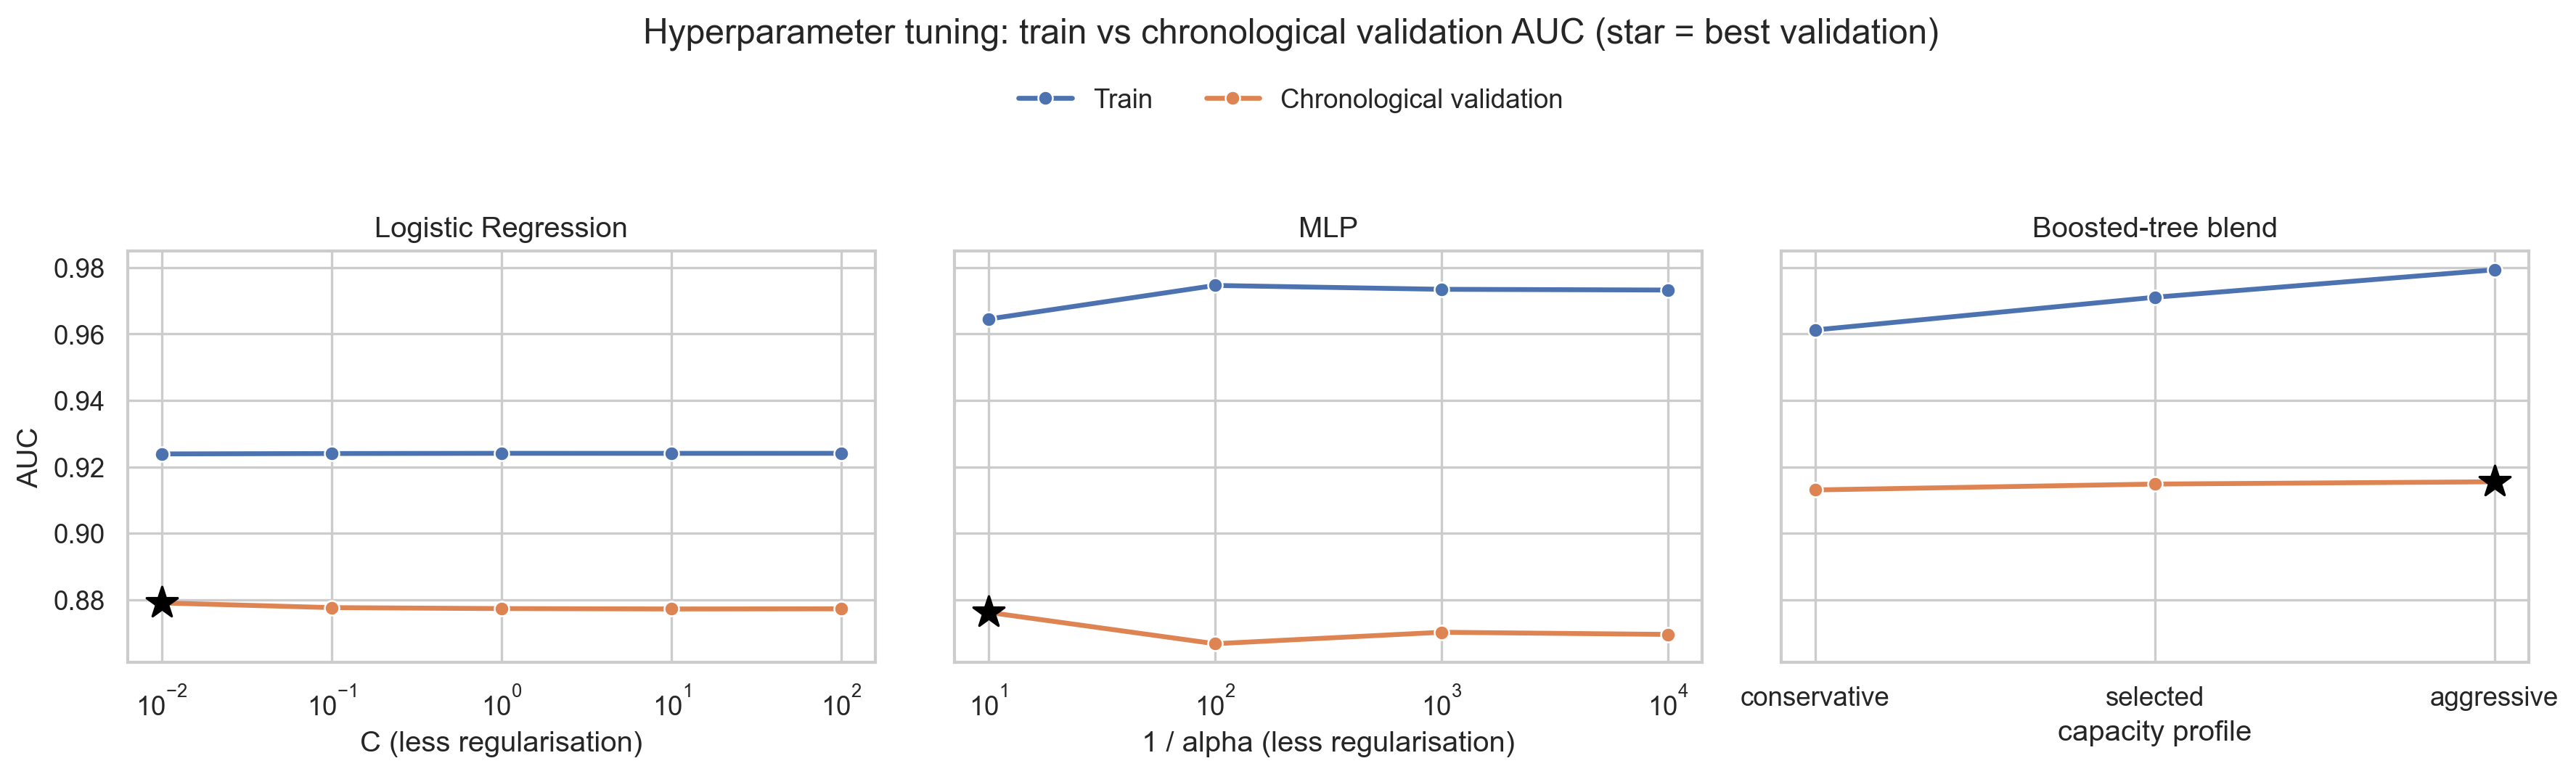

In [25]:
Xtr_enc, Xva_enc = encode_for_continuous_models(Xtr_t, Xva_t)

scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(Xtr_enc)
Xva_scaled = scaler.transform(Xva_enc)

tuning_rows = []

for C in (0.01, 0.1, 1.0, 10.0, 100.0):
    m = LogisticRegression(C=C, max_iter=2000)
    m.fit(Xtr_scaled, y_tr)
    tuning_rows.append({
        "family": "Logistic Regression",
        "setting": f"C={C:g}",
        "capacity": C,
        "x_label": "C (less regularisation)",
        "train_AUC": roc_auc_score(y_tr, m.predict_proba(Xtr_scaled)[:, 1]),
        "chrono_AUC": roc_auc_score(y_va, m.predict_proba(Xva_scaled)[:, 1]),
    })

for alpha in (0.1, 0.01, 0.001, 0.0001):
    m = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        alpha=alpha,
        learning_rate_init=0.001,
        max_iter=150,
        early_stopping=True,
        n_iter_no_change=10,
        random_state=SEED,
    )
    m.fit(Xtr_scaled, y_tr)
    tuning_rows.append({
        "family": "MLP",
        "setting": f"hidden=(64, 32), alpha={alpha:g}",
        "capacity": 1 / alpha,
        "x_label": "1 / alpha (less regularisation)",
        "train_AUC": roc_auc_score(y_tr, m.predict_proba(Xtr_scaled)[:, 1]),
        "chrono_AUC": roc_auc_score(y_va, m.predict_proba(Xva_scaled)[:, 1]),
    })

fast_boosting_budget = {
    "lgbm": dict(n_estimators=300),
    "xgb": dict(n_estimators=300),
    "cat": dict(iterations=500),
}

booster_profiles = [
    (
        "conservative",
        {
            "lgbm": dict(num_leaves=31, min_child_samples=80, reg_lambda=2.0),
            "xgb": dict(max_depth=4, min_child_weight=10, reg_lambda=2.0),
            "cat": dict(depth=4, l2_leaf_reg=6.0),
        },
    ),
    (
        "selected",
        {
            "lgbm": dict(num_leaves=63, min_child_samples=40, reg_lambda=1.0),
            "xgb": dict(max_depth=6, min_child_weight=5, reg_lambda=1.0),
            "cat": dict(depth=6, l2_leaf_reg=3.0),
        },
    ),
    (
        "aggressive",
        {
            "lgbm": dict(num_leaves=127, min_child_samples=20, reg_lambda=0.5),
            "xgb": dict(max_depth=7, min_child_weight=2, reg_lambda=0.5),
            "cat": dict(depth=7, l2_leaf_reg=1.5),
        },
    ),
]

for profile_idx, (profile_name, params_by_model) in enumerate(
    booster_profiles, start=1
):
    train_preds, val_preds = [], []
    for model_name, params in params_by_model.items():
        fit_params = {**fast_boosting_budget[model_name], **params}
        pred_train, pred_val = fit_predict_pair(
            model_name, Xtr_t, y_tr, Xva_t, **fit_params
        )
        tuning_rows.append({
            "family": {
                "lgbm": "LightGBM profile",
                "xgb": "XGBoost profile",
                "cat": "CatBoost profile",
            }[model_name],
            "setting": profile_name,
            "capacity": profile_idx,
            "x_label": "capacity profile",
            "train_AUC": roc_auc_score(y_tr, pred_train),
            "chrono_AUC": roc_auc_score(y_va, pred_val),
        })
        train_preds.append(pred_train)
        val_preds.append(pred_val)
    pred_train_blend = rank_avg(train_preds)
    pred_val_blend = rank_avg(val_preds)
    tuning_rows.append({
        "family": "Boosted-tree blend",
        "setting": profile_name,
        "capacity": profile_idx,
        "x_label": "capacity profile",
        "train_AUC": roc_auc_score(y_tr, pred_train_blend),
        "chrono_AUC": roc_auc_score(y_va, pred_val_blend),
    })

tuning = pd.DataFrame(tuning_rows)
tuning["gap"] = tuning["train_AUC"] - tuning["chrono_AUC"]
tuning["best_chrono"] = (
    tuning.groupby("family")["chrono_AUC"].transform("max").eq(tuning["chrono_AUC"])
)
display(
    tuning.assign(
        train_AUC=lambda d: d["train_AUC"].round(4),
        chrono_AUC=lambda d: d["chrono_AUC"].round(4),
        gap=lambda d: d["gap"].round(4),
    ).sort_values(["family", "capacity"])[
        ["family", "setting", "train_AUC", "chrono_AUC", "gap", "best_chrono"]
    ]
)

plot_tuning = tuning[
    tuning["family"].isin(["Logistic Regression", "MLP", "Boosted-tree blend"])
].melt(
    id_vars=["family", "setting", "capacity", "x_label"],
    value_vars=["train_AUC", "chrono_AUC"],
    var_name="split",
    value_name="AUC",
)
plot_tuning["split"] = plot_tuning["split"].map({
    "train_AUC": "Train",
    "chrono_AUC": "Chronological validation",
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, family in zip(axes, ["Logistic Regression", "MLP", "Boosted-tree blend"]):
    data = plot_tuning[plot_tuning["family"] == family]
    sns.lineplot(
        data=data,
        x="capacity",
        y="AUC",
        hue="split",
        marker="o",
        linewidth=2,
        ax=ax,
    )
    best = tuning[(tuning["family"] == family) & tuning["best_chrono"]].iloc[0]
    ax.scatter(
        best["capacity"],
        best["chrono_AUC"],
        marker="*",
        s=180,
        color="black",
        zorder=5,
    )
    ax.set_title(family)
    ax.set_xlabel(data["x_label"].iloc[0])
    if ax is not axes[0]:
        ax.set_ylabel("")
    if family in ["Logistic Regression", "MLP"]:
        ax.set_xscale("log")
    if family == "Boosted-tree blend":
        profile_labels = (
            tuning[tuning["family"] == family]
            .sort_values("capacity")["setting"]
            .tolist()
        )
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(profile_labels)
    if ax.legend_ is not None:
        ax.legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    "Hyperparameter tuning: train vs chronological validation AUC (star = best validation)",
    y=0.99,
)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False,
)
plt.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

**Reading the tuning plot and table.** Logistic Regression is stable but capped by a linear decision surface. MLP is tuned through its L2 penalty (`alpha`): reducing regularisation gives more flexibility, but the validation gain is limited compared with the extra train fit, which is the expected risk for dense models on medium-sized tabular data. For the boosted-tree family, the table shows a compact sensitivity check for LightGBM, XGBoost, CatBoost, and their **rank-average blend** across conservative, selected, and aggressive profiles. The reduced-round profile search is for model-selection evidence, not an exhaustive grid. In this shortcut search, the aggressive profile is slightly stronger on the holdout for several boosted-tree rows, while the selected profile keeps more moderate tree complexity and regularisation for the current submission builder.


## 7.3 Tuned family comparison on the chronological holdout

After tuning, we compare the selected settings on the same 2017 holdout. Logistic Regression and MLP use the encoded/scaled matrix; the boosters use native categoricals. The boosted-tree row includes the individual implementations and the selected rank-average blend.


In [26]:
# Tuned continuous-input baselines
lr = LogisticRegression(C=1.0, max_iter=2000)
lr.fit(Xtr_scaled, y_tr)
pred_lr = lr.predict_proba(Xva_scaled)[:, 1]

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=150,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=SEED,
)
mlp.fit(Xtr_scaled, y_tr)
pred_mlp = mlp.predict_proba(Xva_scaled)[:, 1]

# Tuned boosted-tree family — reused later for evaluation & the blend
pred_t = {
    name: fit_predict(name, Xtr_t, y_tr, Xva_t) for name in ("lgbm", "xgb", "cat")
}
blend_t = rank_avg(list(pred_t.values()))
blend_prob = np.mean([pred_t[k] for k in pred_t], axis=0)

family_scores = (
    pd
    .DataFrame({
        "model": [
            "Logistic Regression",
            "MLP neural network",
            "LightGBM",
            "XGBoost",
            "CatBoost",
            "Rank-average blend (LGBM+XGB+Cat)",
        ],
        "family": [
            "linear",
            "neural network",
            "boosted-tree family",
            "boosted-tree family",
            "boosted-tree family",
            "selected rank-average blend",
        ],
        "chrono_AUC": [
            roc_auc_score(y_va, pred_lr),
            roc_auc_score(y_va, pred_mlp),
            roc_auc_score(y_va, pred_t["lgbm"]),
            roc_auc_score(y_va, pred_t["xgb"]),
            roc_auc_score(y_va, pred_t["cat"]),
            roc_auc_score(y_va, blend_t),
        ],
    })
    .sort_values("chrono_AUC", ascending=False)
    .reset_index(drop=True)
)
display(family_scores)

,model,family,chrono_AUC
0,Rank-average blend (LGBM+XGB+Cat),selected rank-average blend,0.915618
1,XGBoost,boosted-tree family,0.913536
2,LightGBM,boosted-tree family,0.913464
3,CatBoost,boosted-tree family,0.913025
4,Logistic Regression,linear,0.877344
5,MLP neural network,neural network,0.870219


**The tuned boosters dominate the tuned continuous-input baselines**, confirming the EDA's hint that the signal is non-linear, interaction-driven, and tabular. Logistic Regression is a useful linear reference; the MLP shows that a flexible neural model is not automatically better when the signal lives in categorical splits, missingness, and threshold effects. LightGBM, XGBoost, and CatBoost are three implementations of the same gradient-boosted tree family; in this comparison, their **rank-average blend has the best holdout AUC**. That blend is our selected ranking model.


## 7.4 The key ablation: does the linear time index help?

With the tuned boosted-tree family selected, we test the feature choice that matters most: adding `days_since_epoch`. This ablation uses representative LightGBM rather than refitting the full blend; the goal is to isolate the feature decision while keeping the notebook runnable. We also test a rejected idea (recency sample-weighting).


In [27]:
pred_lgbm_no_time = fit_predict("lgbm", Xtr_n, y_tr, Xva_n)

# rejected idea: down-weight old rows by a 1-year half-life
age = (tr_raw["Course_Start_Date"].max() - tr_raw["Course_Start_Date"]).dt.days
w = np.power(0.5, age / 365.0).values
pred_recency = fit_predict("lgbm", Xtr_t, y_tr, Xva_t, sample_weight=w)

# reference: optimistic random split (leaks the future)
tr_r, va_r = train_test_split(
    train_raw, test_size=0.2, random_state=SEED, stratify=train_raw[TARGET]
)
fm_r = make_freq_maps(tr_r, va_r)
Xtr_r = build_features(tr_r, fm_r)
Xva_r = build_features(va_r, fm_r)
align_categories(Xtr_r, Xva_r)
pred_random = fit_predict("lgbm", Xtr_r, tr_r[TARGET].values, Xva_r)

ablation = pd.DataFrame({
    "configuration": [
        "LightGBM, no time index",
        "LightGBM, + time index",
        "LightGBM + recency weights (rejected)",
        "LightGBM, random split (optimistic — do NOT trust)",
    ],
    "AUC": [
        roc_auc_score(y_va, pred_lgbm_no_time),
        roc_auc_score(y_va, pred_t["lgbm"]),
        roc_auc_score(y_va, pred_recency),
        roc_auc_score(va_r[TARGET].values, pred_random),
    ],
    "validation": ["chrono", "chrono", "chrono", "random"],
})
display(ablation)

,configuration,AUC,validation
0,"LightGBM, no time index",0.911242,chrono
1,"LightGBM, + time index",0.913464,chrono
2,LightGBM + recency weights (rejected),0.912230,chrono
3,"LightGBM, random split (optimistic — do NOT tr...",0.963738,random


**What the table shows.**

- Adding the **time index improves LightGBM on the future holdout** — the
  counter-intuitive win. It only shows up _because_ we validate on the future; a
  random split would have hidden (or reversed) it.
- **This recency weighting setting is rejected**: a 1-year half-life on
  LightGBM did not help beyond the time index. Other decay rates were not
  explored in this compact notebook.
- The **random split scores far higher (~0.96)** than any honest chrono number —
  exactly the trap the first attempt fell into (random CV 0.944 → leaderboard 0.886). We ignore
  it.

### First attempt vs selected pipeline, on the same footing

In prior notebook/pipeline experiments on identical splits, the selected pipeline beat the first approach (date dropped, top-$k$ collapse, one-hot, single XGBoost) on **both** protocols — so the gain was not just an artefact of changing metrics:

| Pipeline                                            | Random 80/20 | Chrono holdout |
| --------------------------------------------------- | ------------ | -------------- |
| First attempt (drop date, one-hot, single XGB)      | ≈ 0.940      | ≈ 0.905        |
| **Selected chronological pipeline (this notebook)** | ≈ 0.962      | **≈ 0.916**    |

Comparing against the known first-attempt gap (0.905 chrono → 0.886 real) suggested the selected pipeline's ~0.916 chrono score should land near **0.89 on the leaderboard**, consistent with the scored file's **0.889314**.


# 8. Model evaluation

AUC is the competition metric, but operations act on a **threshold**. We evaluate the chosen blend on the chronological holdout with ROC and precision–recall curves. For confusion-matrix diagnostics, we use the mean boosted-tree probability (`blend_prob`), because the submitted rank-average score (`blend_t`) is optimized for ranking and is not calibrated.


## 8.1 ROC & precision–recall curves


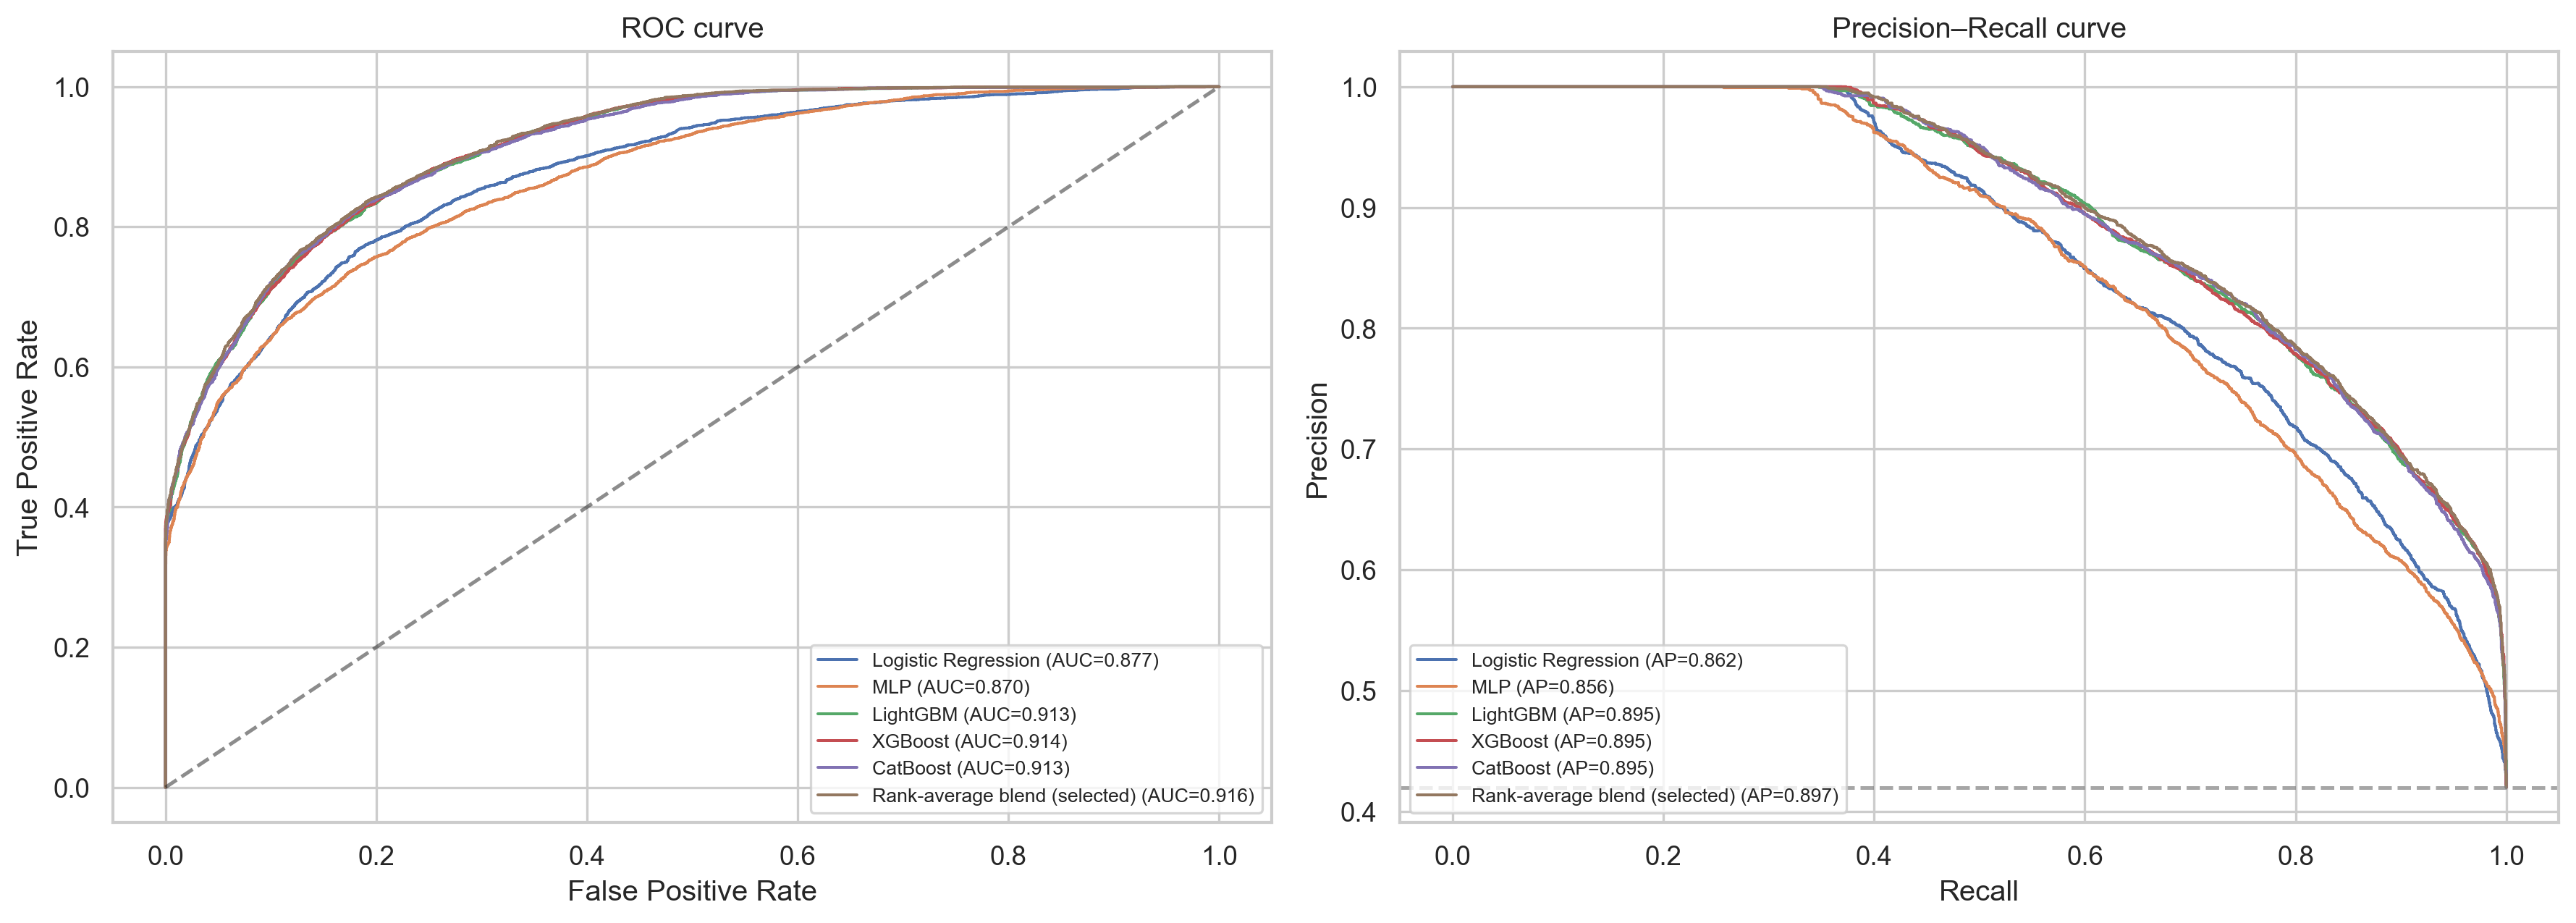

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for pred, name in [
    (pred_lr, "Logistic Regression"),
    (pred_mlp, "MLP"),
    (pred_t["lgbm"], "LightGBM"),
    (pred_t["xgb"], "XGBoost"),
    (pred_t["cat"], "CatBoost"),
    (blend_t, "Rank-average blend (selected)"),
]:
    fpr, tpr, _ = roc_curve(y_va, pred)
    axes[0].plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc(fpr, tpr):.3f})",
        lw=2.2 if name.startswith("Blend") else 1.2,
    )
    prec, rec, _ = precision_recall_curve(y_va, pred)
    axes[1].plot(
        rec,
        prec,
        label=f"{name} (AP={average_precision_score(y_va, pred):.3f})",
        lw=2.2 if name.startswith("Blend") else 1.2,
    )
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set(
    xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC curve"
)
axes[0].legend(loc="lower right", fontsize=8)
axes[1].axhline(y_va.mean(), ls="--", color="grey", alpha=0.7)
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall curve")
axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

The blend has the best holdout AUC in this comparison, so it is the selected ranking score.


## 8.2 Confusion matrix & threshold metrics

At the default 0.5 threshold we turn the mean boosted-tree probabilities into hard decisions and read off the operational metrics. This is a diagnostic threshold, not the submitted rank-average score.


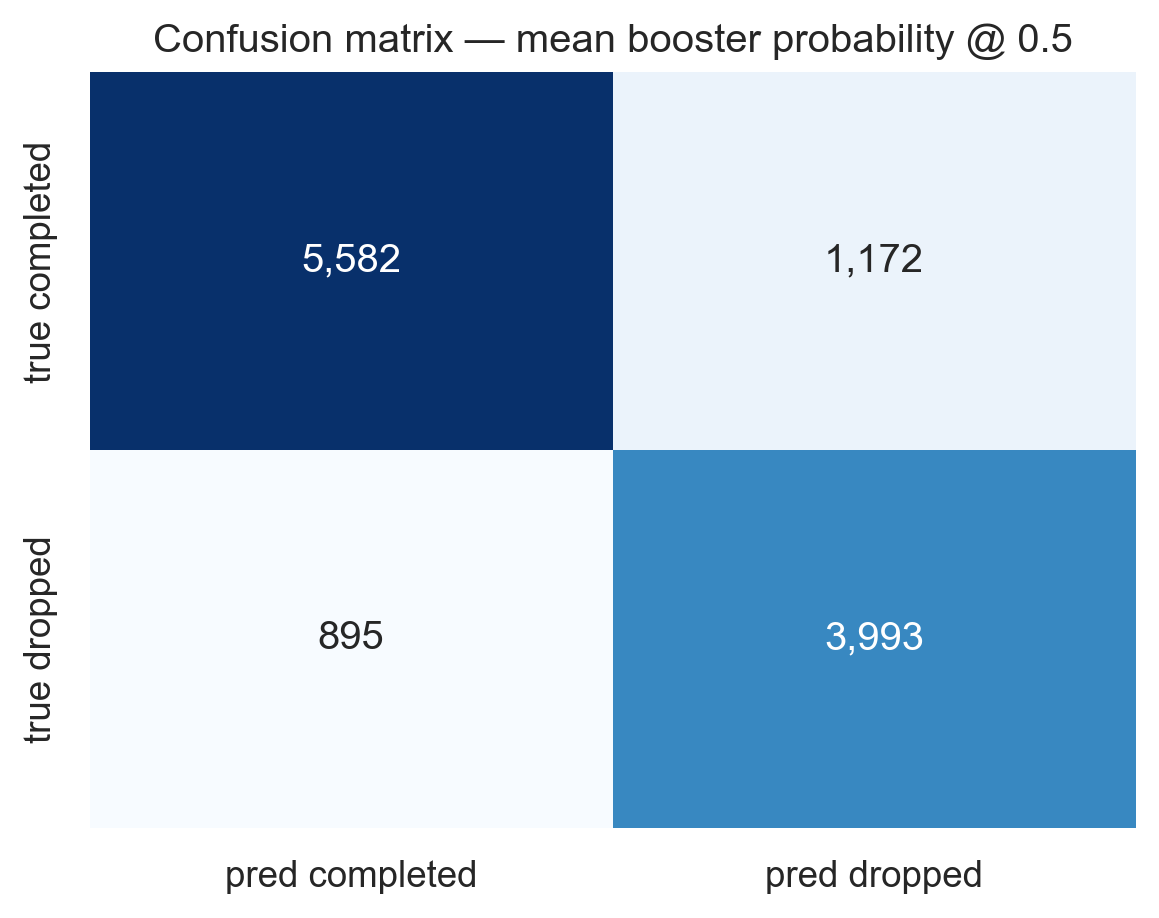

              precision    recall  f1-score   support

   completed      0.862     0.826     0.844      6754
     dropped      0.773     0.817     0.794      4888

    accuracy                          0.822     11642
   macro avg      0.817     0.822     0.819     11642
weighted avg      0.825     0.822     0.823     11642

AUC of selected rank-average score: 0.9156
AUC of mean booster probability: 0.9156


In [29]:
y_hat = (blend_prob >= 0.5).astype(int)
cm = confusion_matrix(y_va, y_hat)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["pred completed", "pred dropped"],
    yticklabels=["true completed", "true dropped"],
    ax=ax,
)
ax.set_title("Confusion matrix — mean booster probability @ 0.5")
plt.tight_layout()
plt.show()

print(
    classification_report(y_va, y_hat, target_names=["completed", "dropped"], digits=3)
)
print(f"AUC of selected rank-average score: {roc_auc_score(y_va, blend_t):.4f}")
print(f"AUC of mean booster probability: {roc_auc_score(y_va, blend_prob):.4f}")

**What each metric means here.**

- **Precision (dropped)** — of the orders we flag as high-risk, how many really
  cancel. Low precision ⇒ we waste follow-up effort / overbook wrongly.
- **Recall (dropped)** — of the orders that really cancel, how many we catch.
  Low recall ⇒ we get blindsided by cancellations.
- **Accuracy / F1** — overall correctness; useful but threshold-dependent.

Because operations can trade these off by moving the threshold (and the grade is AUC), we submit a continuous risk score, not hard labels. If the business needs the score to read as a true probability, a separate calibration step should be added.


## 8.3 Where is the model unsure?

The distribution of mean boosted-tree probabilities shows how many borderline cases the representative probability diagnostic produces.


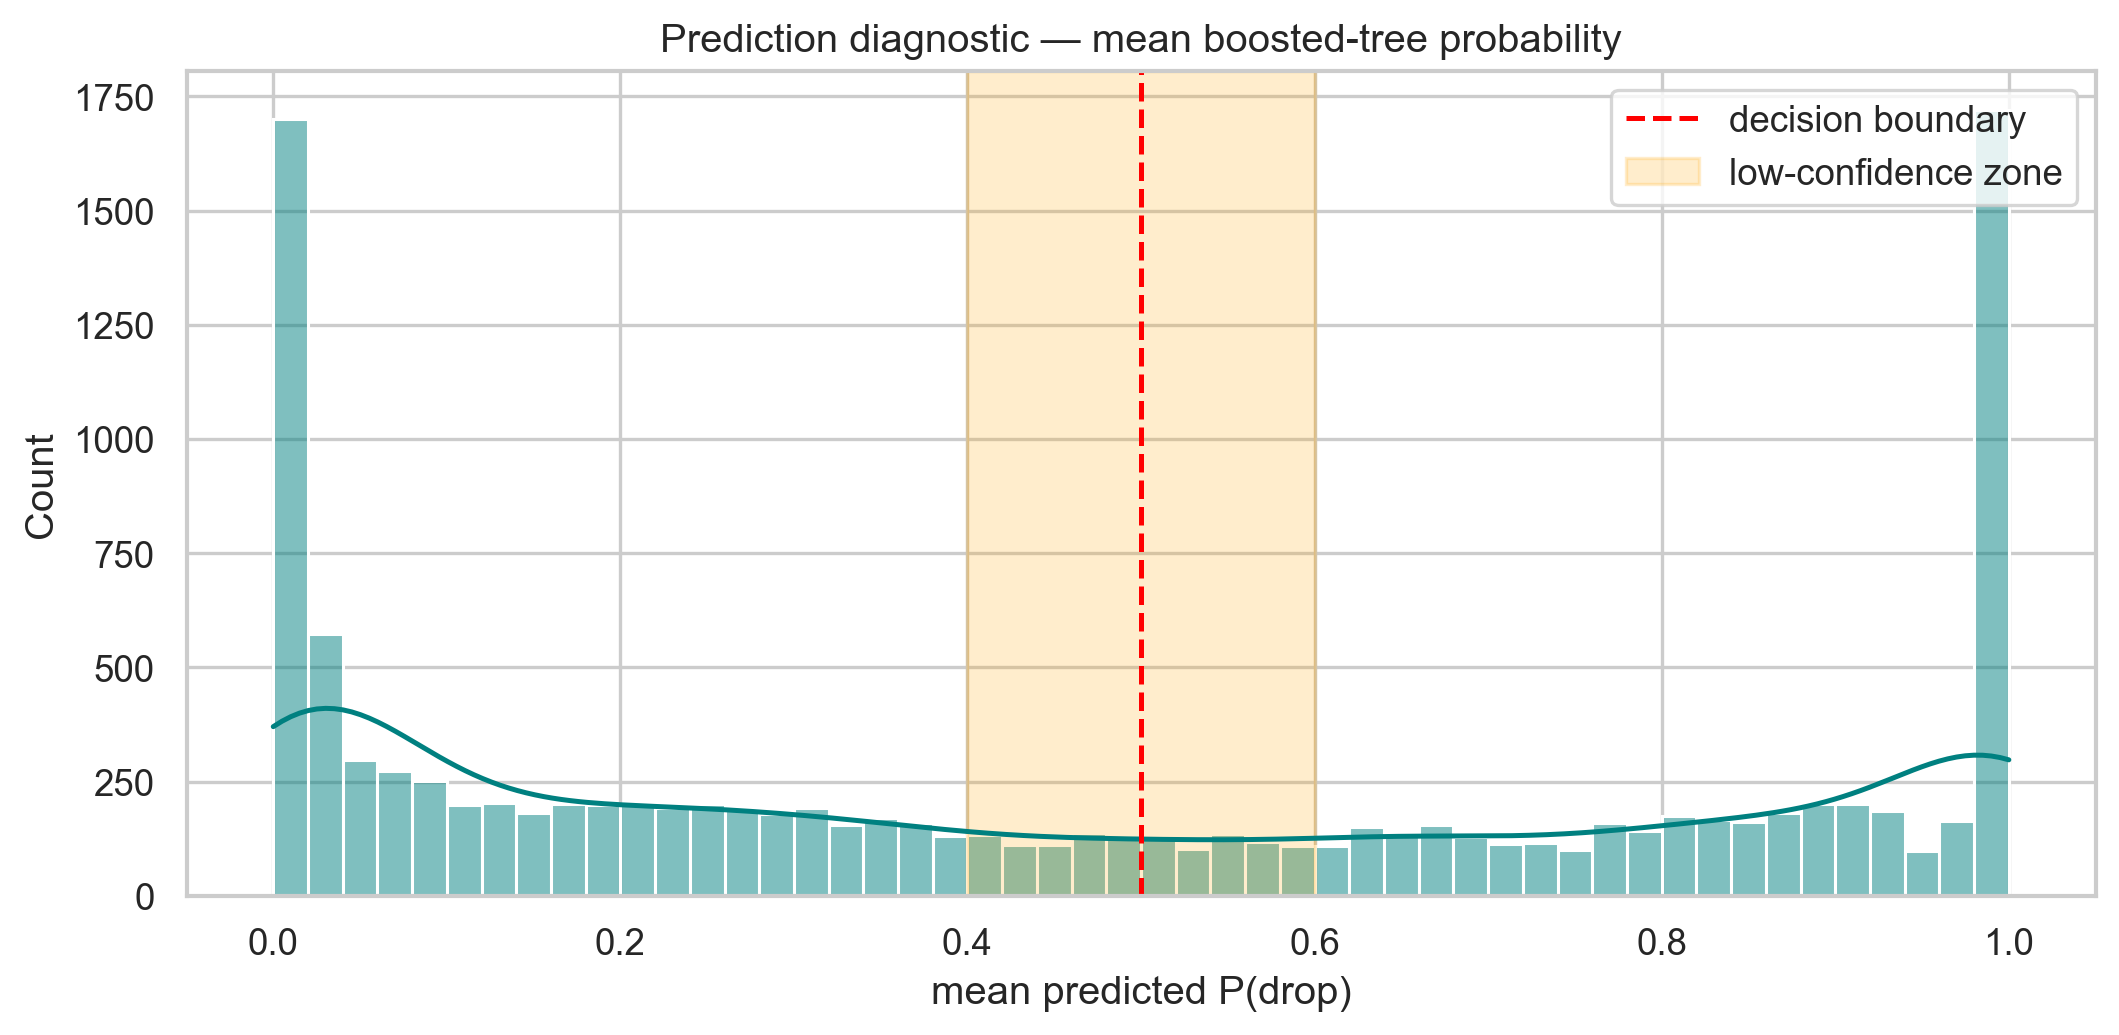

share of holdout in the 0.40–0.60 low-confidence zone: 10.5%


In [30]:
plt.figure(figsize=(9, 4.5))
sns.histplot(blend_prob, bins=50, kde=True, color="teal")
plt.axvline(0.5, color="red", ls="--", label="decision boundary")
plt.axvspan(0.40, 0.60, color="orange", alpha=0.2, label="low-confidence zone")
plt.xlabel("mean predicted P(drop)")
plt.title("Prediction diagnostic — mean boosted-tree probability")
plt.legend()
plt.tight_layout()
plt.show()

uncertain = ((blend_prob > 0.40) & (blend_prob < 0.60)).mean() * 100
print(f"share of holdout in the 0.40–0.60 low-confidence zone: {uncertain:.1f}%")

The probability diagnostic is separate from the submitted rank score. Cases in the 0.4–0.6 band are useful examples of orders where the representative models are less separated. We dig into _why_ one such case lands there using SHAP next.


# 9. Interpretation with SHAP

For interpretation we analyse **one** representative model — **LightGBM+time** — as the assignment requires. This is not SHAP for the selected rank-average blend: it uses a fixed sample of up to 2,000 chronological-validation rows from one representative LightGBM model. SHAP (SHapley Additive exPlanations) attributes each prediction to its features via a game-theoretic allocation, giving both global importance and per-observation explanations.


In [31]:
shap_model = LGBMClassifier(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=40,
    subsample=0.9,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)
shap_model.fit(
    Xtr_t, y_tr, categorical_feature=Xtr_t.select_dtypes("category").columns.tolist()
)
print(
    f"LightGBM+time chrono AUC: {roc_auc_score(y_va, shap_model.predict_proba(Xva_t)[:, 1]):.4f}"
)

X_shap = Xva_t.sample(min(2000, len(Xva_t)), random_state=SEED)
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
shap_values = np.asarray(shap_values)
if shap_values.ndim == 3:  # some shap versions return (n, features, classes)
    shap_values = shap_values[:, :, 1]

LightGBM+time chrono AUC: 0.9135


## 9.1 Global importance (beeswarm + bar)


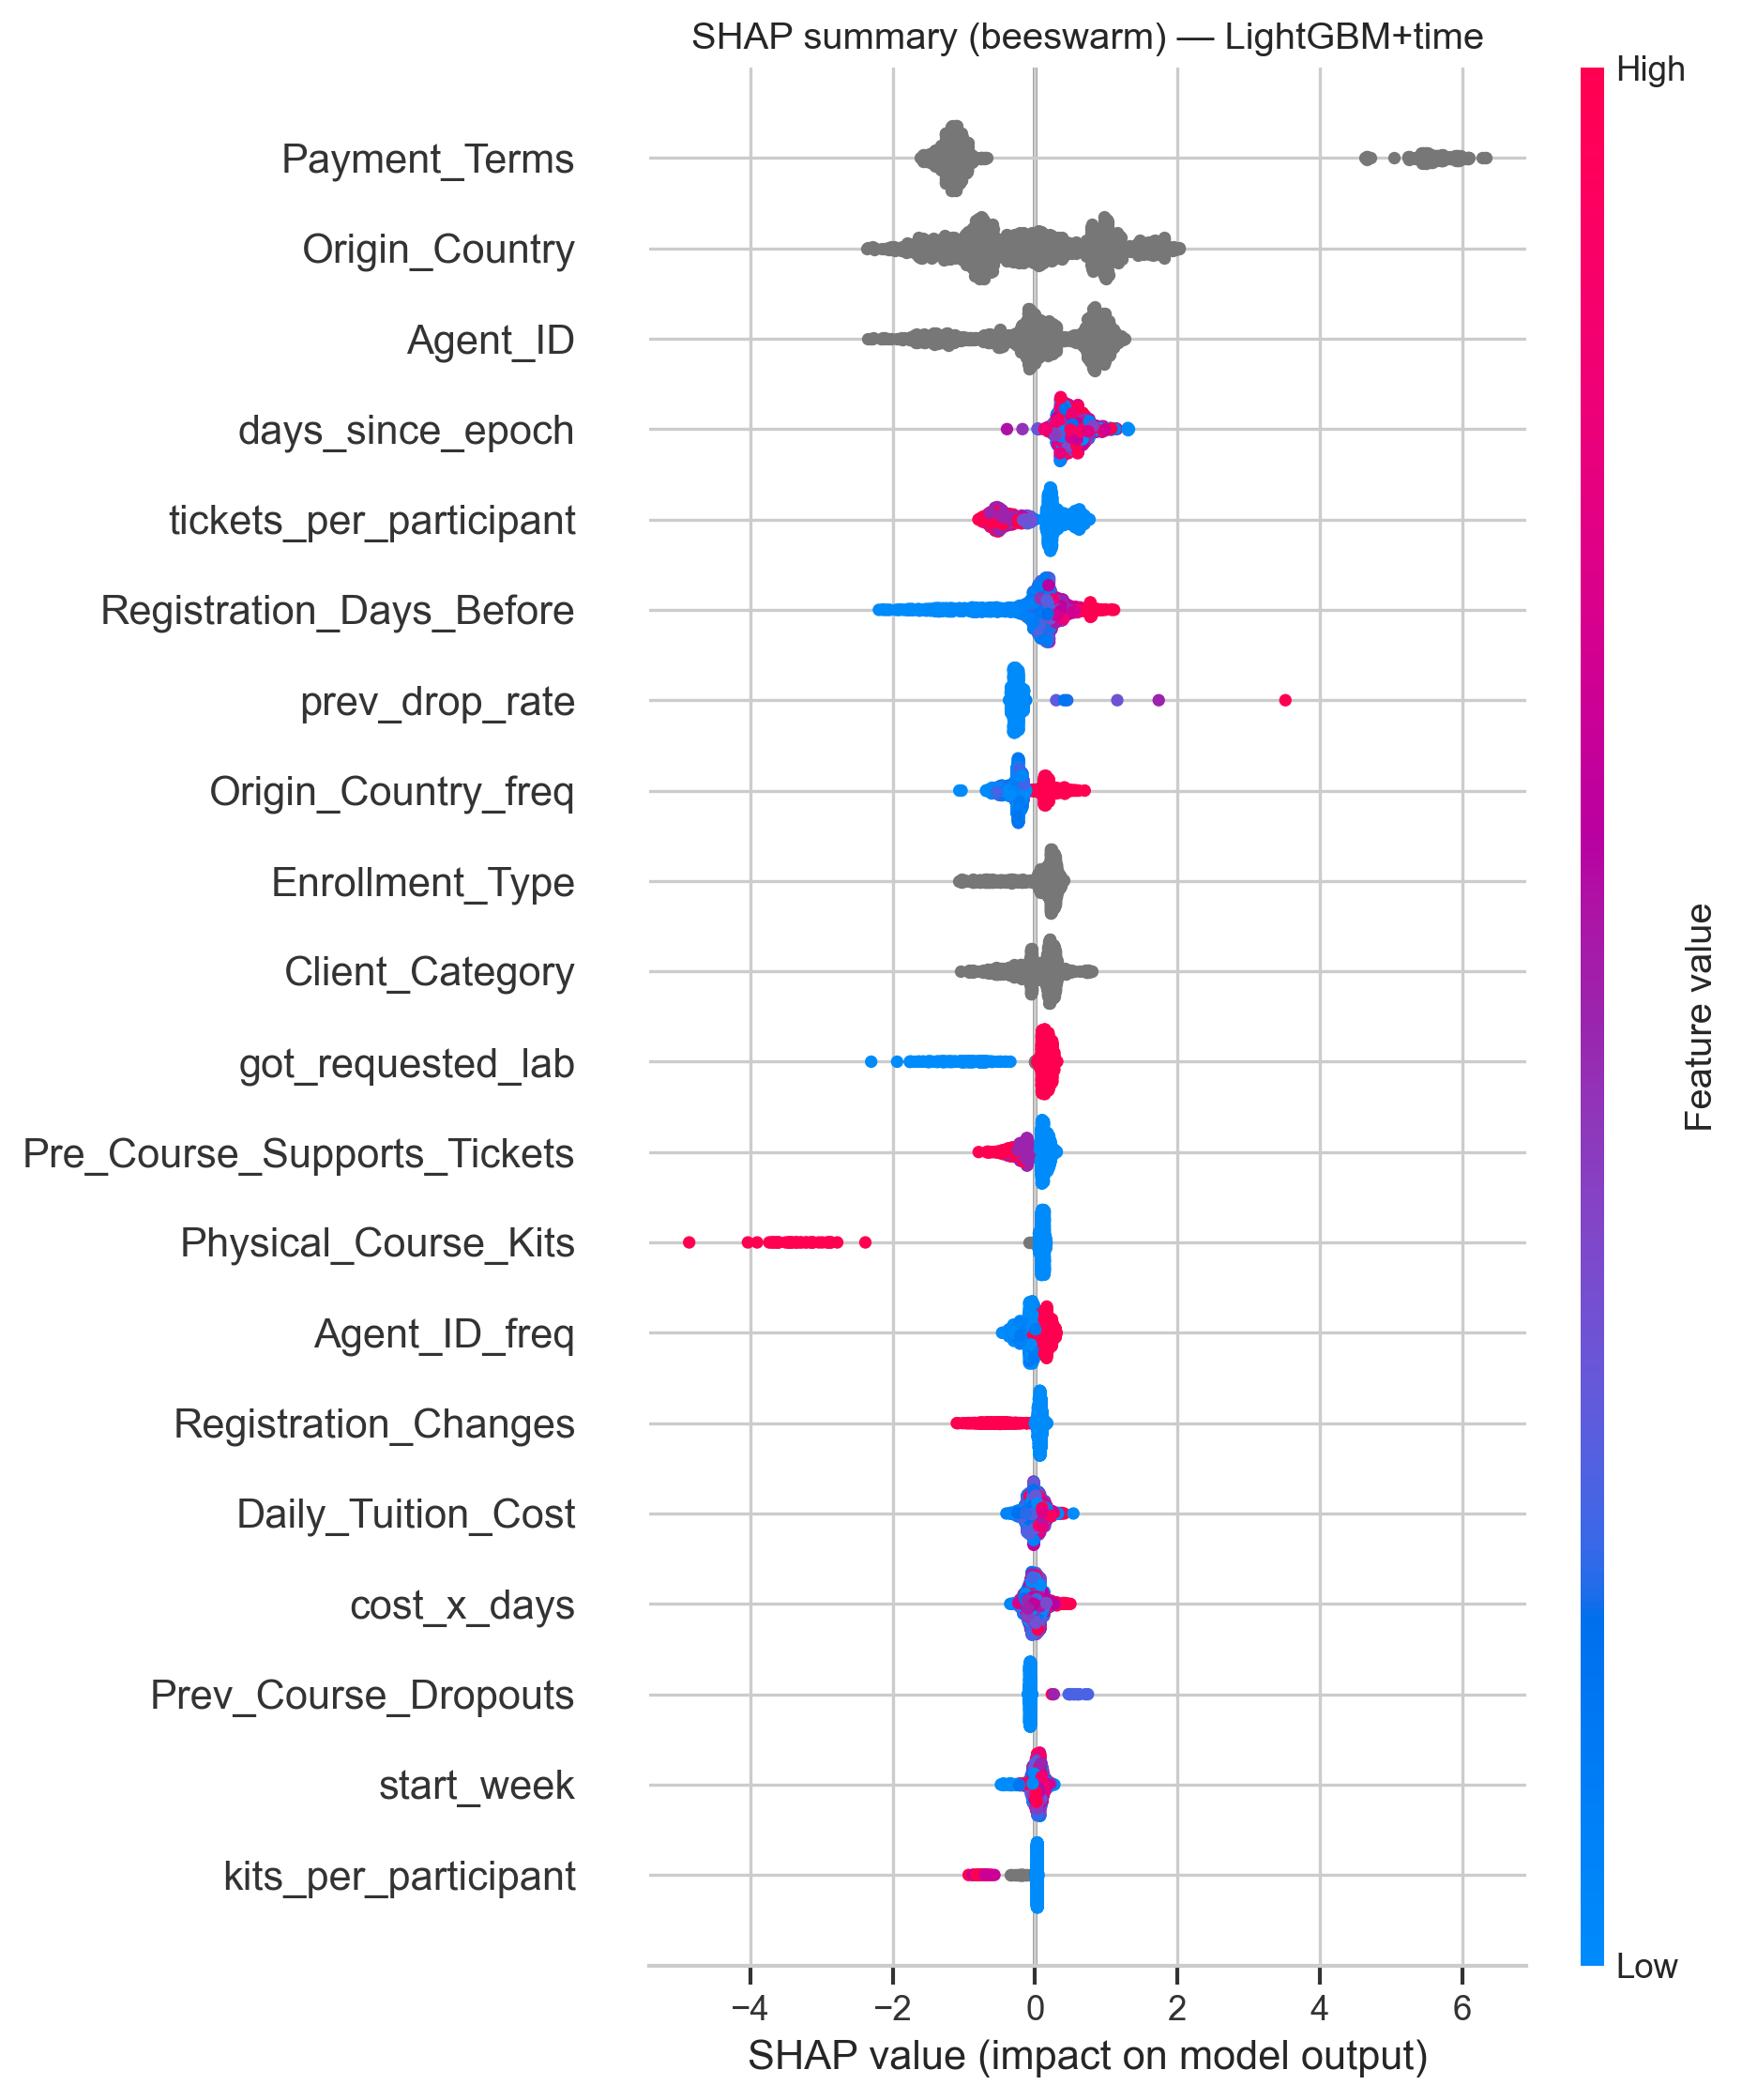

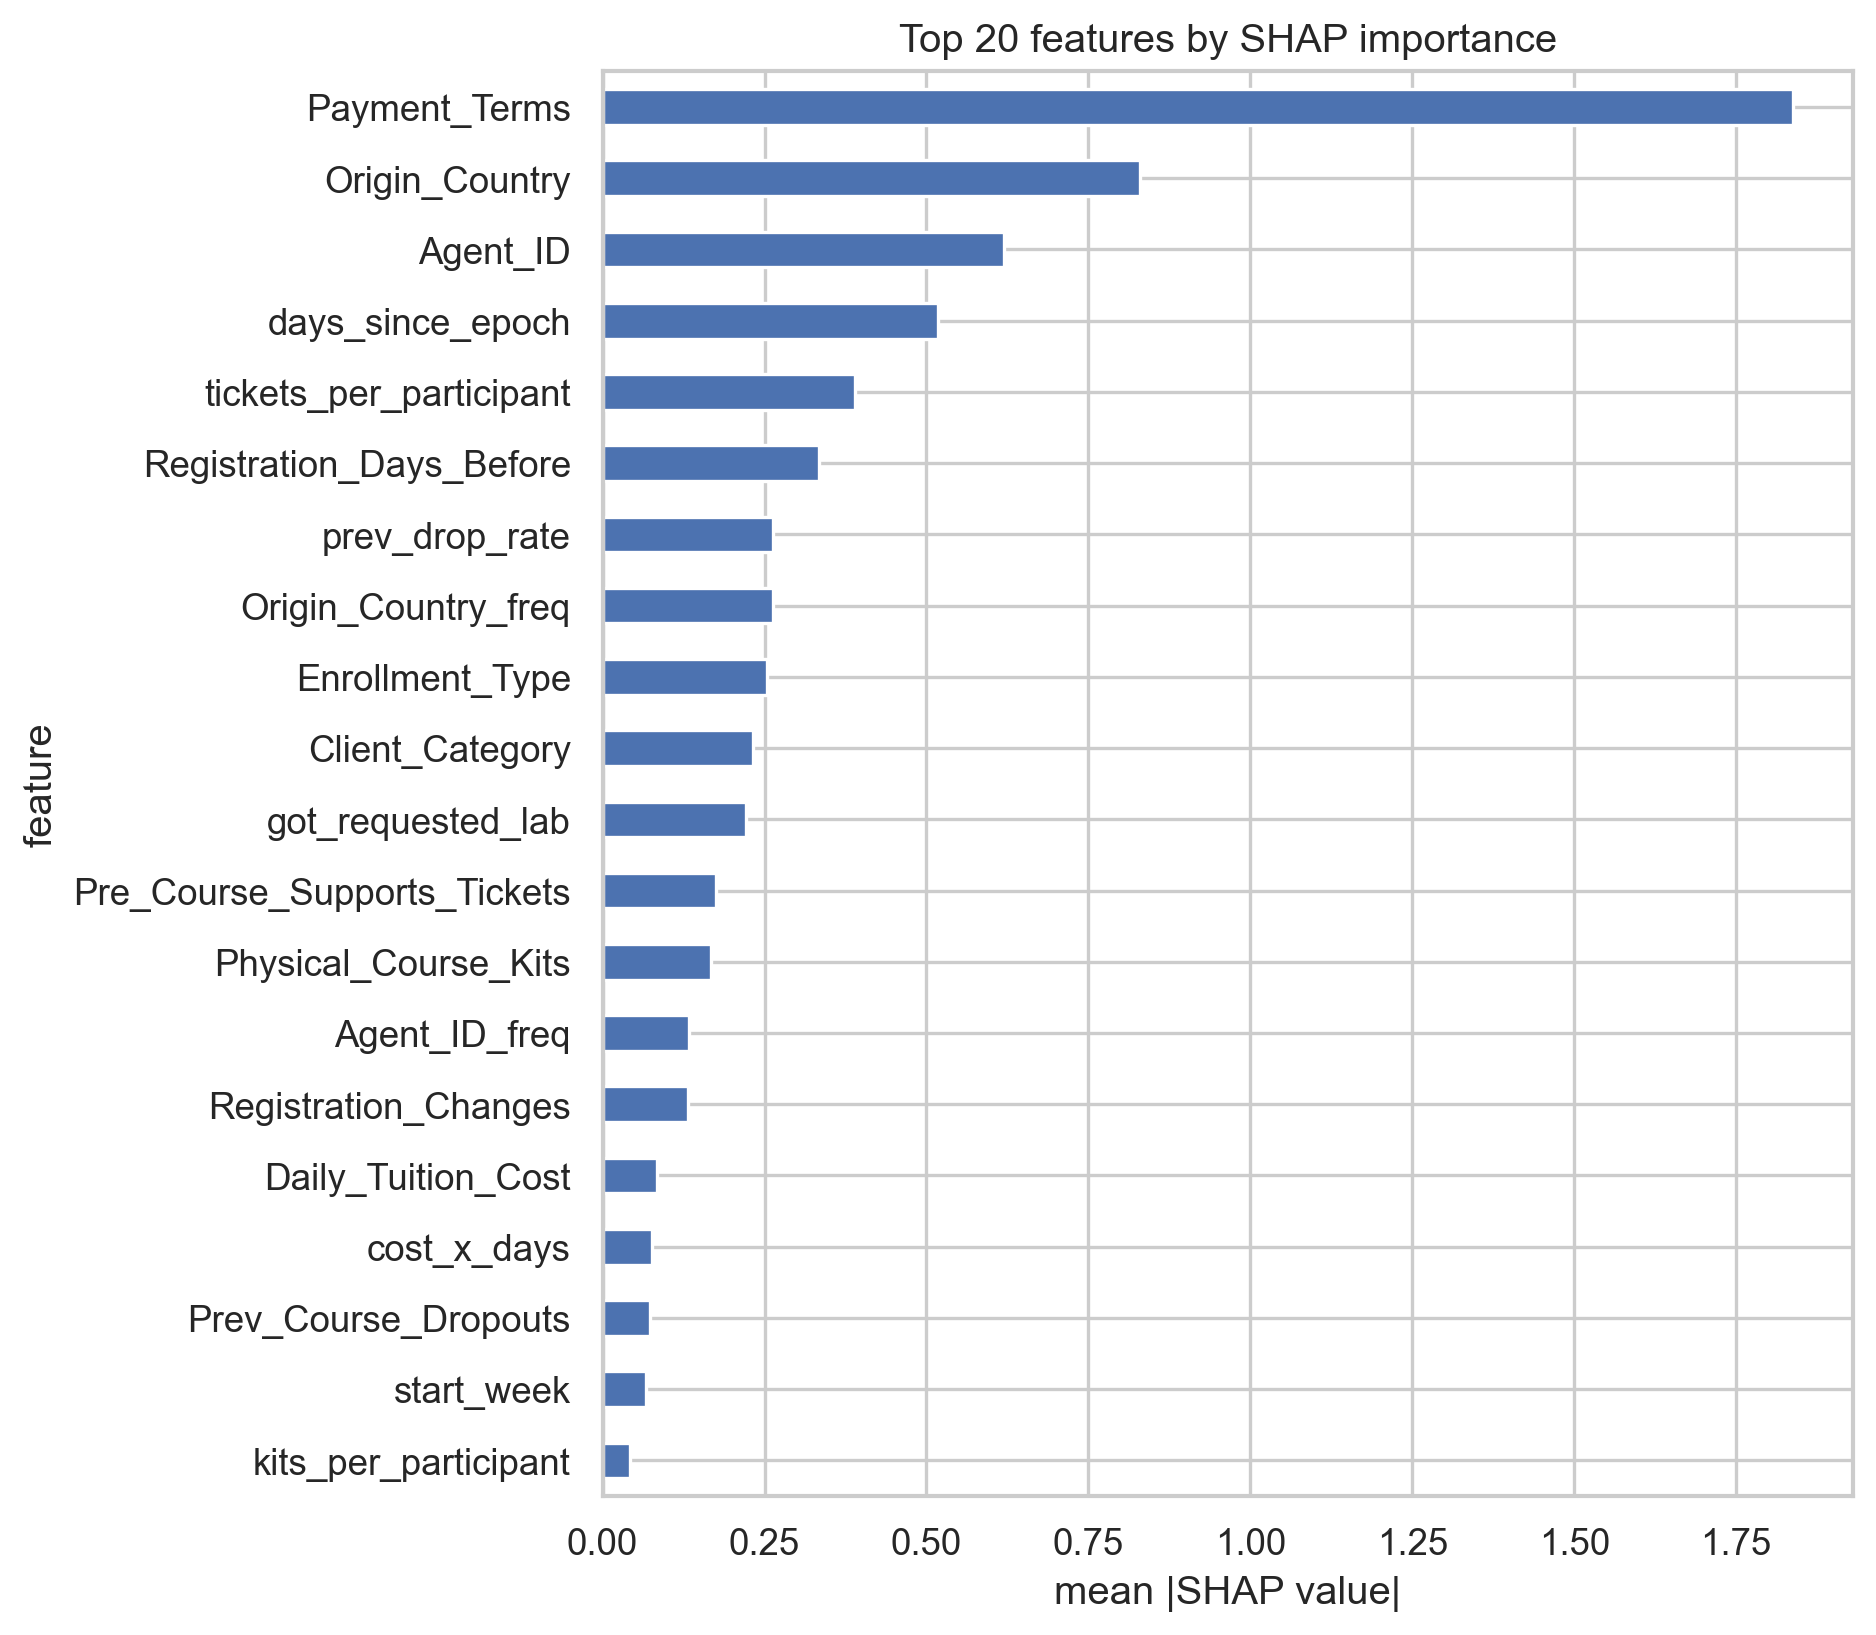

,feature,mean_abs_shap
0,Payment_Terms,1.838496
1,Origin_Country,0.830426
2,Agent_ID,0.619574
3,days_since_epoch,0.517341
4,tickets_per_participant,0.389720
5,Registration_Days_Before,0.333383
6,prev_drop_rate,0.262812
7,Origin_Country_freq,0.262718
8,Enrollment_Type,0.253015
9,Client_Category,0.231775


In [32]:
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
plt.title("SHAP summary (beeswarm) — LightGBM+time")
plt.tight_layout()
plt.show()

importance = (
    pd
    .DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(0),
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
top = importance.head(20)
ax = top.sort_values("mean_abs_shap").plot.barh(
    x="feature", y="mean_abs_shap", legend=False, figsize=(8, 7), color="#4c72b0"
)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Top 20 features by SHAP importance")
plt.tight_layout()
plt.show()
display(top)

**Reading the SHAP importance.** The drivers line up with the EDA: `Payment_Terms`, the **time index** (`days_since_epoch`) and seasonality, the **frequency-encoded IDs** (`Agent_ID_freq`, `Company_ID_freq`), registration timing, and the engineered **history/ratio** features. The prominence of the time index is consistent with the representative LightGBM ablation in Section 7.4: this representative model uses _when_ an order occurs to score the future window.

### The `Payment_Terms` leakage plausibility assessment

EDA flagged prepaid-non-refundable as suspiciously strong. SHAP confirms it is influential, but SHAP importance alone cannot prove absence of leakage. We therefore run one small sensitivity check: refit representative LightGBM without `Payment_Terms` and compare chronological AUC.


In [33]:
pred_lgbm_no_payment = fit_predict(
    "lgbm",
    Xtr_t.drop(columns=["Payment_Terms"]),
    y_tr,
    Xva_t.drop(columns=["Payment_Terms"]),
)
payment_check = pd.DataFrame({
    "model": ["LightGBM + time", "LightGBM + time, no Payment_Terms"],
    "chrono_AUC": [
        roc_auc_score(y_va, pred_t["lgbm"]),
        roc_auc_score(y_va, pred_lgbm_no_payment),
    ],
})
payment_check["delta_vs_with_payment"] = (
    payment_check["chrono_AUC"] - payment_check.loc[0, "chrono_AUC"]
)
display(payment_check)

,model,chrono_AUC,delta_vs_with_payment
0,LightGBM + time,0.913464,0.000000
1,"LightGBM + time, no Payment_Terms",0.906128,-0.007336


The feature remains useful in this representative check, but that is still not a data-lineage proof. The working assumption is that payment terms are set _at registration_ (before cancellation), making them a plausible early risk signal rather than a post-hoc label leak. Before production use, the timing should be confirmed with the data owner.


## 9.2 Dependence view for the top signal


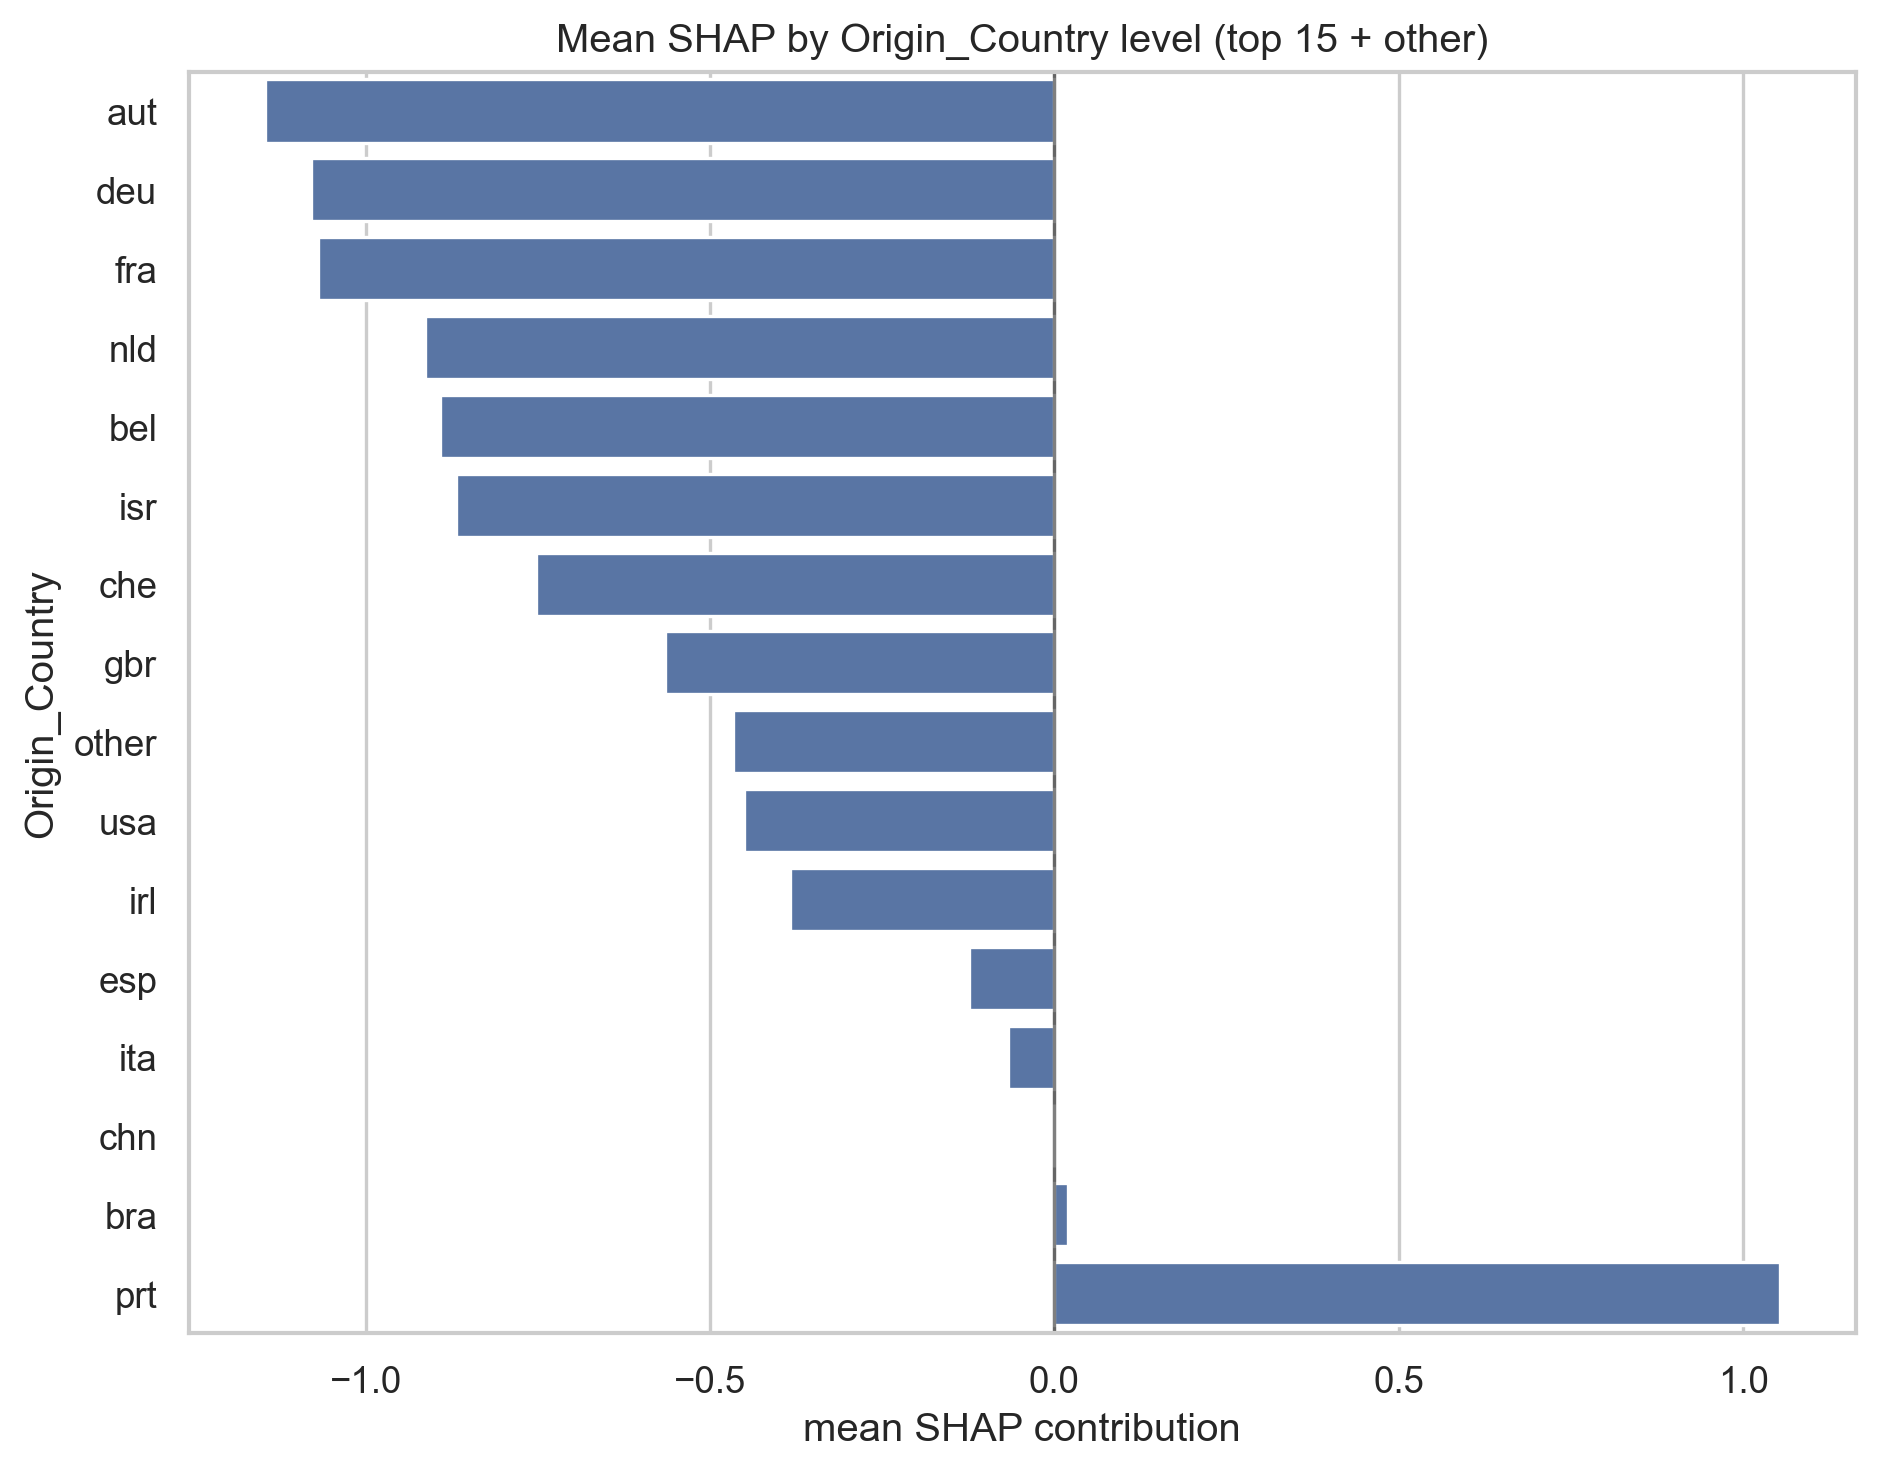

In [34]:
top_feat = (
    importance.loc[importance["feature"] != "Payment_Terms", "feature"].iloc[0]
    if importance["feature"].iloc[0] == "Payment_Terms"
    else importance["feature"].iloc[0]
)


def plot_shap_dependence_readable(feature, max_categories=15):
    col_idx = list(X_shap.columns).index(feature)
    values = X_shap[feature]
    is_categorical = (
        str(values.dtype) == "category"
        or values.dtype == "object"
        or values.nunique(dropna=False) <= max_categories
    )

    if not is_categorical:
        shap.dependence_plot(
            feature, shap_values, X_shap, interaction_index=None, show=False
        )
        plt.title(f"SHAP dependence — {feature}")
        plt.tight_layout()
        plt.show()
        return

    labels = values.astype("string").fillna("missing")
    keep = labels.value_counts().head(max_categories).index
    grouped = pd.DataFrame({
        "level": labels.where(labels.isin(keep), "other"),
        "shap": shap_values[:, col_idx],
    })
    summary = (
        grouped
        .groupby("level", observed=True)
        .agg(mean_shap=("shap", "mean"), n=("shap", "size"))
        .sort_values("mean_shap")
    )

    fig_h = max(4, min(7, 0.32 * len(summary) + 1.2))
    fig, ax = plt.subplots(figsize=(8, fig_h))
    sns.barplot(
        data=summary.reset_index(),
        y="level",
        x="mean_shap",
        color="#4c72b0",
        ax=ax,
    )
    ax.axvline(0, color="black", lw=1, alpha=0.5)
    ax.set_title(f"Mean SHAP by {feature} level (top {max_categories} + other)")
    ax.set_xlabel("mean SHAP contribution")
    ax.set_ylabel(feature)
    plt.tight_layout()
    plt.show()


try:
    plot_shap_dependence_readable(top_feat)
except Exception as e:
    print(f"(dependence view skipped for {top_feat}: {e})")

## 9.3 Explaining a single low-confidence order

To answer "_how_ does the model handle uncertain observations?", we pick one illustrative LightGBM sample case near P(drop) ≈ 0.5 and decompose its prediction. The waterfall shows which features pushed the score up vs down.


explaining order at sample position 10 — model P(drop)=0.476


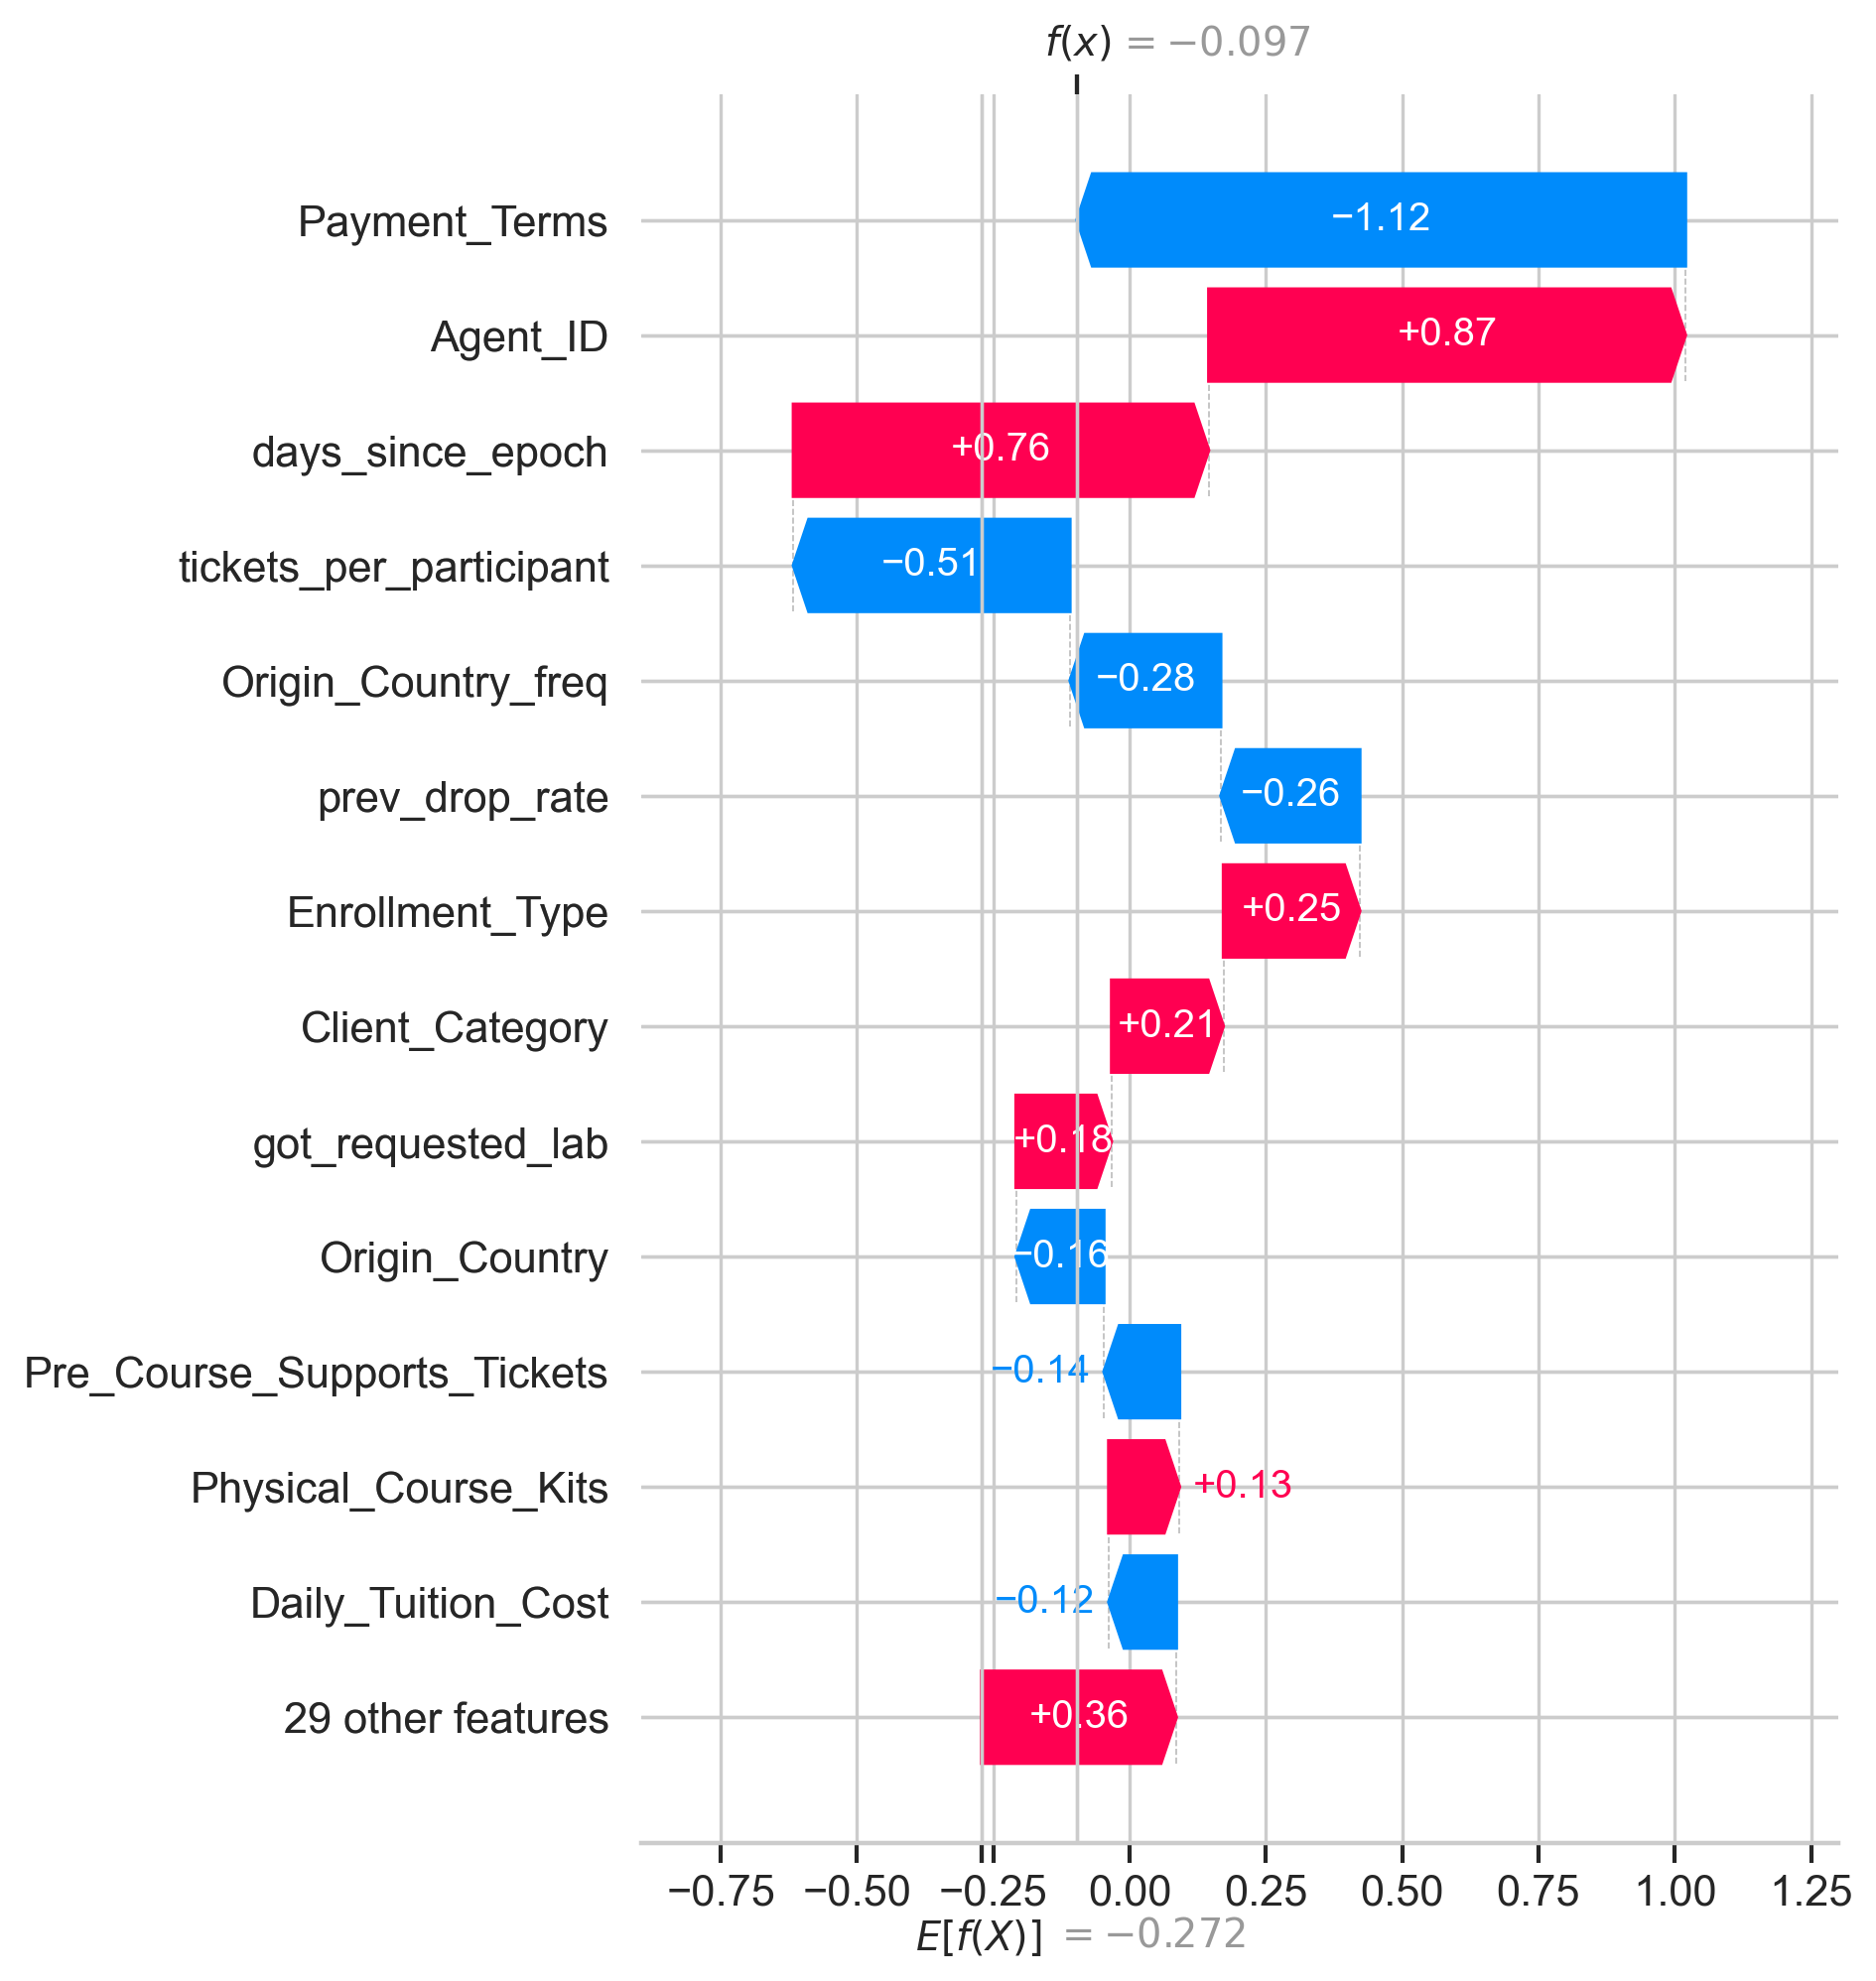

In [35]:
sample_scores = shap_model.predict_proba(X_shap)[:, 1]
borderline = np.where((sample_scores > 0.45) & (sample_scores < 0.55))[0]
idx = int(borderline[0]) if len(borderline) else 0
base = explainer.expected_value
if isinstance(base, (list, np.ndarray)):
    base = np.asarray(base).ravel()[-1]

print(
    f"explaining order at sample position {idx} — model P(drop)={sample_scores[idx]:.3f}"
)
shap.plots._waterfall.waterfall_legacy(
    base,
    shap_values[idx],
    feature_names=list(X_shap.columns),
    max_display=14,
    show=False,
)
plt.tight_layout()
plt.show()

For this illustrative borderline order, the positive and negative contributions nearly balance in the representative LightGBM model. Operationally, cases like this are natural candidates for human follow-up because the model score is near the decision boundary.


# 10. Current submission model & CSV builder

We refit all three boosters on **every** labelled row, build label-free frequency maps from train+test covariates for the submission scoring transform, rank-average their test predictions, and optionally write the submission CSV. This mirrors `pipelines/pipeline_v2.py`. The train+test frequency maps are a transductive shortcut: they use no target labels, but they do use test covariate frequencies.


In [36]:
def build_submission(out_path="data/Group_27_Submission_v3.csv", write=False):
    fm = make_freq_maps(train_raw, test_raw)
    X_train_full = build_features(train_raw, fm)
    X_test = build_features(test_raw, fm)
    align_categories(X_train_full, X_test)
    y_full = train_raw[TARGET].values

    preds = []
    for name in ("lgbm", "xgb", "cat"):
        preds.append(fit_predict(name, X_train_full, y_full, X_test))
        print(f"fitted {name} on {len(X_train_full):,} rows")

    submission = pd.DataFrame({
        "Client_ID": test_raw["Client_ID"],
        "Drop_Probability": rank_avg(preds),
    })
    if write:
        submission.to_csv(out_path, index=False)
        print(f"wrote {out_path}  ({len(submission):,} rows)")
    return submission


# Set write=True to (re)generate the CSV. We write to a *v3* path so we never
# clobber the officially-scored data/Group_27_Submission.csv by accident.
submission = build_submission(write=False)
display(submission.head())
print(submission["Drop_Probability"].describe())

scored_path = Path("data/Group_27_Submission.csv")
if scored_path.exists():
    scored_submission = pd.read_csv(scored_path)
    comparison = scored_submission.merge(
        submission,
        on="Client_ID",
        suffixes=("_scored_file", "_rebuilt"),
        validate="one_to_one",
    )
    diff = (
        comparison["Drop_Probability_scored_file"]
        - comparison["Drop_Probability_rebuilt"]
    ).abs()
    submission_match = pd.DataFrame({
        "rows_compared": [len(comparison)],
        "max_abs_diff": [diff.max()],
        "mean_abs_diff": [diff.mean()],
        "spearman_corr": [
            comparison["Drop_Probability_scored_file"].corr(
                comparison["Drop_Probability_rebuilt"], method="spearman"
            )
        ],
    })
    display(submission_match)
    if diff.max() < 1e-12:
        print("rebuilt predictions match the scored file exactly.")
    else:
        print(
            "rebuilt predictions are not byte-identical to the scored file; "
            "use the stored scored CSV as the official leaderboard record."
        )
else:
    print(f"{scored_path} not found; skipped scored-file comparison.")

fitted lgbm on 63,464 rows
fitted xgb on 63,464 rows
fitted cat on 63,464 rows


,Client_ID,Drop_Probability
0,62246,0.220555
1,43031,0.959473
2,26571,0.243918
3,77694,0.961080
4,22185,0.495231


count    15866.000000
mean         0.500032
std          0.287224
min          0.000252
25%          0.251765
50%          0.503771
75%          0.749312
max          0.998939
Name: Drop_Probability, dtype: float64


,rows_compared,max_abs_diff,mean_abs_diff,spearman_corr
0,15866,0.096202,0.011032,0.998639


rebuilt predictions are not byte-identical to the scored file; use the stored scored CSV as the official leaderboard record.


The output has the required schema (`Client_ID`, `Drop_Probability`), one row per test order, with rank-average risk scores spread across `[0, 1]`. When the local officially scored file is available, the comparison table above verifies whether this notebook's rebuilt current logic matches it exactly or only approximately. If the max difference is non-zero, the stored scored CSV remains the source of truth for the reported leaderboard result.


# 11. Current conclusions — executive summary

**The problem.** Predict the probability a B2B course registration is cancelled, so Nova Academy can stop sinking cost into orders that will fall through.

**The process.** A CRISP-DM-style pass: EDA → cleaning → feature engineering → chronologically-validated modelling → evaluation → SHAP interpretation.

**The central discovery.** _The test set is the future._ Train ends where test begins, and the drop rate drifts over time (confirmed by adversarial validation, AUC ≫ 0.5). This reframed the task as forecasting and made a

**chronological holdout** — not a random split — the yardstick used for model decisions. It helped reveal why changes that look small in random CV matter for the future-window test.

**What worked.**

1. **Time-aware validation** — every decision judged on a future window.
2. **Thorough categorical cleaning** + **label-free frequency encoding**, so
   dirty high-cardinality IDs became usable without a one-hot explosion (our
   answer to the curse of dimensionality).
3. **Domain-driven features** — composition/ratio/history features and, counter
   to intuition, a **linear time index** that lets trees score future rows in
   the latest regime.
4. **A rank-average blend** of LightGBM + XGBoost + CatBoost, three
   implementations of one gradient-boosted tree family, which had the best
   holdout AUC in this comparison.

**Key findings for the business.** The strongest, actionable drivers are payment
terms (prepaid-non-refundable is high-risk — worth a process review), the registration channel and enrolment type, agent/company identity and the presence of a company id, how early the group registered, and pre-course engagement (support tickets ⇒ commitment).

**Current scored result.** The locally available scored CSV is associated with
leaderboard **AUC 0.889314 — 1st of 32 groups**, far above the 0.70 bar.

**Ways to push further (not yet implemented).**

- Rolling multi-fold time-series CV for tuning (vs the single chrono holdout).
- Careful leave-one-out / target encoding of `Agent_ID` / `Company_ID` (leakage
  risk — must be fit inside CV folds).
- Confirm the `Payment_Terms` signal with the data owner before leaning on it in
  production.
- Probability **calibration** (isotonic/Platt) if the business needs the scores
  to read as true probabilities rather than just a good ranking.
